# 1. Definición del problema

**Contexto.** Cada año ocurren miles de eventos meteorológicos (tormentas con viento, granizo,
inundaciones, tornados, calor extremo, etc.). La gran mayoría no causa daños importantes, pero unos pocos provocan
muertes, heridos o pérdidas económicas grandes.

**Necesidad.** Las instituciones que responden a emergencias no pueden dar la misma prioridad a todos los eventos.
Sería útil estimar, apenas se reporta un evento, qué tan probable es que termine siendo de alto impacto.

**Unidad de análisis.** Un evento registrado en la base de datos (una fila = un `EVENT_ID`).

**Momento de predicción (t₀).** Queremos estimar el riesgo usando solo la información que razonablemente estaría
disponible al inicio del evento o en su primer reporte: tipo de evento, ubicación, fecha y hora de inicio y, cuando aplica,
la magnitud reportada (viento o granizo). En t₀ todavía no se sabe cuándo termina el evento, cuántas víctimas o daños deja,
ni la información que se agrega al documentarlo después (por ejemplo, la escala EF de un tornado o las narrativas).

**Limitación de este planteamiento.** Storm Events es una base histórica que NOAA revisa y publica después de los eventos;
no es un registro en tiempo real. Por eso *simulamos* la predicción temprana eligiendo solo variables compatibles con t₀
(ver la auditoría de variables al final de la sección 4). Como los valores de esas variables ya fueron revisados, los
resultados serán una estimación optimista de lo que pasaría en un uso real.

**Pregunta principal.**
> Con la información disponible en t₀ (tipo de evento, ubicación, fecha de inicio y magnitud reportada),
> ¿en qué medida podemos identificar los eventos de **alto impacto documentado** mejor que una referencia simple
> basada solo en el tipo de evento?

**Definición de alto impacto documentado (definida por nosotros).** El dataset no trae esta columna, así que la construimos:
un evento es de alto impacto documentado si su registro tiene **al menos una víctima** (muertes o heridos, directos o indirectos)
**o** un **daño documentado de 1 millón de USD o más** (propiedad + cultivos). Decimos *documentado* porque muchos eventos
no tienen información de daño: un 0 significa que el registro no documenta un alto impacto, no que el evento no lo haya tenido
(ver 3.0). El umbral de USD 1 millón es una decisión de trabajo del equipo, no una definición oficial de NOAA.

**Tipo de problema.** Clasificación binaria supervisada (alto impacto documentado = 1, resto = 0).

**Utilidad esperada.** Ayudar a entender qué tipos de eventos y condiciones conviene vigilar con más atención y
ver si un modelo simple puede dar una lista priorizada de eventos apenas se reportan.

**Criterios para considerar útil el resultado.**
- Que el modelo supere a un baseline trivial (predecir siempre la clase mayoritaria), cuyo PR-AUC es igual a la prevalencia (≈ 1.4 %).
- Que mejore frente a una referencia simple: la tasa de alto impacto de cada tipo de evento, calculada solo con los datos de entrenamiento.
- Que se evalúe con métricas adecuadas para clases muy desbalanceadas: principalmente PR-AUC (*Average Precision*), junto con
  precision, recall y la matriz de confusión. La accuracy no será la métrica principal; la justificación formal irá en la sección de evaluación.
- Que los modelos se comparen con train y validation. El test se separa en el TP1, pero queda sellado hasta la evaluación final.
- Que los resultados se puedan interpretar (qué variables pesan y por qué), no solo reportar métricas.

# 2. Dataset y procedencia

- **Fuente:** NOAA / NCEI — *Storm Events Database* (archivo de detalle de eventos, `StormEvents_details`).
  Página oficial: https://www.ncei.noaa.gov/stormevents/
- **Archivo:** `StormEvents_details-ftp_v1.0_d2025_c20260819.csv.gz` (versión creada por NCEI el 19/08/2026).
  Las instrucciones de descarga están en `data/README.md`.
- **Procedencia:** la base la arma el Servicio Meteorológico Nacional de EE. UU. (NWS) a partir de reportes de oficinas del NWS,
  observadores, medios, autoridades locales, etc.
- **Licencia / uso:** la ficha de metadatos de NCEI
  ([gov.noaa.ncdc:C00510](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00510))
  no indica una licencia específica. Sus condiciones de uso piden citar el dataset (*"Cite dataset when used as a source"*)
  y advierten que el NWS no garantiza la exactitud de la información.
- **Cita:** NOAA National Centers for Environmental Information (NCEI). *Storm Events Database*, archivo
  `StormEvents_details-ftp_v1.0_d2025_c20260819.csv.gz`. https://www.ncei.noaa.gov/stormevents/
- **Período:** año 2025
- **¿Por qué este dataset?** Es una fuente oficial con más de 72 mil eventos de un año, y cada registro trae tanto la
  información inicial del evento (tipo, lugar, fecha, magnitud) como su impacto documentado (víctimas y daños),
  que necesitamos para construir el target.

**Limitaciones conocidas del dataset**
- Es una base histórica: NCEI publica los datos unos 75 días después del fin de cada mes
  ([Storm Events FAQ](https://www.ncei.noaa.gov/stormevents/faq.jsp)). No es información en tiempo real.
- Los daños son estimaciones (NCEI pide considerarlos *"a broad estimate"*) y muchos están vacíos. Un vacío no significa daño cero (ver 3.0).
- Algunos tipos de evento solo se registran si hubo impacto: el NWS define *Lightning* como un rayo que causa muertes, heridos o
  daño importante ([Directiva NWS 10-1605](https://www.nws.noaa.gov/directives/sym/pd01016005curr.pdf)). Además, las prácticas de
  registro varían entre oficinas y estados (ver 3.0 y sección 4).
- Un mismo fenómeno puede aparecer como varios eventos (uno por condado o zona), y solo usamos datos de 2025 de EE. UU.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os

url = "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2025_c20260819.csv.gz"
archivo = os.path.basename(url)

# Si existe una copia local en data/raw/ se lee esa; si no (por ejemplo, en Colab), se lee directamente desde NOAA
if os.path.exists(f"../data/raw/{archivo}"):      # notebook abierto desde la carpeta notebooks/
    ruta = f"../data/raw/{archivo}"
elif os.path.exists(f"data/raw/{archivo}"):       # notebook ejecutado desde la raíz del repositorio
    ruta = f"data/raw/{archivo}"
else:                                             # Colab: URL oficial de NOAA
    ruta = url

df = pd.read_csv(ruta, compression="gzip", low_memory=False)

print(f"Datos: {df.shape[0]:,} registros")
print(f"Leído desde: {ruta}")

In [ ]:
df.head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,202503,31,1104,202503,31,1106,201366,1252415,GEORGIA,13,...,2.22,W,TYUS,33.4757,-85.238,33.4757,-85.238,A cold-front initiated a line of thunderstorms...,Tree down at the intersection of highway 5 and...,CSV
1,202503,30,1552,202503,30,1555,200337,1241136,MICHIGAN,26,...,1.47,NNE,EDWARDSBURG,41.7900,-86.100,41.8200,-86.070,A cold front pushed into the area during the a...,A brief EF-1 tornado was confirmed in Edwardsb...,CSV
2,202501,5,1800,202501,6,2227,197733,1222851,VIRGINIA,51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure tracked across souther...,NaN,CSV
3,202501,3,1300,202501,3,1900,197761,1223112,MARYLAND,24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure moved off into New Eng...,NaN,CSV
4,202501,3,1300,202501,3,1900,197761,1223113,MARYLAND,24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure moved off into New Eng...,NaN,CSV


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72360 entries, 0 to 72359
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BEGIN_YEARMONTH     72360 non-null  int64  
 1   BEGIN_DAY           72360 non-null  int64  
 2   BEGIN_TIME          72360 non-null  int64  
 3   END_YEARMONTH       72360 non-null  int64  
 4   END_DAY             72360 non-null  int64  
 5   END_TIME            72360 non-null  int64  
 6   EPISODE_ID          72360 non-null  int64  
 7   EVENT_ID            72360 non-null  int64  
 8   STATE               72360 non-null  object 
 9   STATE_FIPS          72360 non-null  int64  
 10  YEAR                72360 non-null  int64  
 11  MONTH_NAME          72360 non-null  object 
 12  EVENT_TYPE          72360 non-null  object 
 13  CZ_TYPE             72360 non-null  object 
 14  CZ_FIPS             72360 non-null  int64  
 15  CZ_NAME             72360 non-null  object 
 16  WFO 

In [ ]:
df["EVENT_TYPE"].value_counts()

,count
EVENT_TYPE,
Thunderstorm Wind,21807
Hail,9205
Flash Flood,5393
High Wind,4603
Winter Weather,4436
Drought,3283
Winter Storm,3070
Heat,2864
Flood,2261


In [ ]:
print("Observaciones:", df.shape[0])
print("Variables:", df.shape[1])

fechas = pd.to_datetime(df["BEGIN_DATE_TIME"], format="%d-%b-%y %H:%M:%S", errors="coerce")
print("Primer evento:", fechas.min())
print("Último evento:", fechas.max())
print("Estados / regiones distintos:", df["STATE"].nunique())
print("Tipos de evento distintos:", df["EVENT_TYPE"].nunique())

# Guardamos los nombres de las 51 columnas originales (se usan en la auditoría de variables, sección 4)
COLUMNAS_RAW = df.columns.tolist()

Observaciones: 72360
Variables: 51
Primer evento: 2025-01-01 00:00:00


Último evento: 2025-12-31 23:40:00
Estados / regiones distintos: 68
Tipos de evento distintos: 48


### Diccionario de variables relevantes

In [ ]:
diccionario = pd.DataFrame({
    "variable": ["EVENT_ID", "EPISODE_ID", "EVENT_TYPE", "STATE", "CZ_TYPE", "CZ_NAME",
                 "BEGIN_DATE_TIME", "END_DATE_TIME", "MONTH_NAME", "SOURCE",
                 "MAGNITUDE", "MAGNITUDE_TYPE", "TOR_F_SCALE",
                 "BEGIN_LAT / BEGIN_LON",
                 "DEATHS_DIRECT / DEATHS_INDIRECT", "INJURIES_DIRECT / INJURIES_INDIRECT",
                 "DAMAGE_PROPERTY / DAMAGE_CROPS", "alto_impacto (nueva)",
                 "estado_dano (nueva)", "viento_kt / granizo_in (nuevas)"],
    "descripcion": [
        "Identificador único del evento",
        "Identificador del episodio (sistema meteorológico que agrupa varios eventos)",
        "Tipo de evento (Hail, Tornado, Flash Flood, etc.)",
        "Estado o zona marítima donde ocurrió",
        "C = condado, Z = zona de pronóstico (NOAA define también M = marina; en 2025 las zonas marinas vienen como Z)",
        "Nombre del condado o zona",
        "Fecha y hora de inicio (texto; según NOAA, normalmente en hora local estándar)",
        "Fecha y hora de fin (texto; según NOAA, normalmente en hora local estándar)",
        "Mes del evento",
        "Fuente del reporte (público, NWS, medios, etc.); si hubo varias, quien prepara el registro elige una",
        "Magnitud: nudos en eventos de viento, pulgadas en granizo; vacía en los demás tipos (no aplica)",
        "Solo viento: EG ráfaga estimada, ES sostenido estimado, MG ráfaga medida, MS sostenido medido",
        "Escala EF del tornado, asignada según el daño causado (EF0 a EF5; EFU = desconocida)",
        "Coordenadas de inicio del evento",
        "Muertes directas e indirectas",
        "Heridos directos e indirectos",
        "Daño estimado en USD, como texto (ej. 1.00K, 0.50M); vacío = sin información, no cero",
        "Variable objetivo: alto impacto documentado (1 si el registro tiene víctimas o daño >= 1 millón de USD)",
        "Estado del daño total: sin_info / cero / positivo",
        "Magnitud separada por unidad: nudos (viento) y pulgadas (granizo); vacía si no aplica"],
    "tipo": ["identificador", "identificador", "categórica", "categórica", "categórica", "categórica",
             "fecha (texto)", "fecha (texto)", "categórica", "categórica",
             "numérica", "categórica", "categórica", "numérica",
             "numérica", "numérica", "texto con unidad", "objetivo (0/1)",
             "categórica", "numérica"]
})
diccionario

,variable,descripcion,tipo
0,EVENT_ID,Identificador único del evento,identificador
1,EPISODE_ID,Identificador del episodio (sistema meteorológ...,identificador
2,EVENT_TYPE,"Tipo de evento (Hail, Tornado, Flash Flood, etc.)",categórica
3,STATE,Estado o zona marítima donde ocurrió,categórica
4,CZ_TYPE,"C = condado, Z = zona de pronóstico (NOAA defi...",categórica
5,CZ_NAME,Nombre del condado o zona,categórica
6,BEGIN_DATE_TIME,"Fecha y hora de inicio (texto; según NOAA, nor...",fecha (texto)
7,END_DATE_TIME,"Fecha y hora de fin (texto; según NOAA, normal...",fecha (texto)
8,MONTH_NAME,Mes del evento,categórica
9,SOURCE,"Fuente del reporte (público, NWS, medios, etc....",categórica


# 3. Análisis exploratorio de datos (EDA)

Preguntas que queremos responder:

| # | Pregunta | Para qué nos sirve |
|---|----------|--------------------|
| P1 | ¿Cuántos eventos son de alto impacto? | Ver si las clases están balanceadas |
| P2 | ¿Cómo se distribuyen los eventos, los daños y las víctimas? | Entender los datos y decidir qué hacer con valores extremos |
| P3 | ¿Cambia el alto impacto según el tipo de evento? | Ver si el tipo es una variable útil |
| P4 | ¿Hay patrón por mes? | Ver si el tiempo ayuda |
| P5 | ¿Cambia según quién reporta el evento? | Detectar posibles problemas de interpretación |
| P6 | ¿Se diferencian los grupos en duración e intensidad? | Ver si las variables físicas ayudan |
| P7 | ¿Hay anomalías? | Detectar casos raros que condicionen la preparación |

Para poder armar el objetivo necesitamos primero convertir los daños de texto (`"1.00K"`) a número.
La validación detallada de esta conversión está en la sección 4.



## 3.0 Construcción de la variable objetivo

El target es **alto impacto documentado**: 1 si el registro tiene al menos una víctima o un daño documentado de
USD 1 millón o más. Para construirlo convertimos los daños de texto a número y distinguimos tres situaciones:
daño **positivo**, **cero** informado explícitamente (por ejemplo `0.00K`) y **sin información** (celda vacía).
Un vacío no se trata como cero: en esos eventos simplemente no sabemos el daño.

In [ ]:
MULT = {"K": 1e3, "M": 1e6, "B": 1e9}

def convertir_dano(x):
    """'1.50K' -> 1500.0 ; '0' -> 0.0 ; vacío -> NaN (sin información, no es cero)"""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s == "0":
        return 0.0
    return float(s[:-1]) * MULT[s[-1]]

df["dano_propiedad"] = df["DAMAGE_PROPERTY"].apply(convertir_dano)
df["dano_cultivos"]  = df["DAMAGE_CROPS"].apply(convertir_dano)
df["dano_total"]     = df[["dano_propiedad", "dano_cultivos"]].sum(axis=1, min_count=1)  # vacío solo si faltan ambos

# Estado del daño: diferenciamos "sin información" de "cero informado"
df["estado_dano"] = np.select([df["dano_total"].isna(), df["dano_total"] == 0],
                              ["sin_info", "cero"], default="positivo")

df["victimas"] = (df["DEATHS_DIRECT"] + df["DEATHS_INDIRECT"]
                  + df["INJURIES_DIRECT"] + df["INJURIES_INDIRECT"])

# Alto impacto documentado: un daño vacío nunca cuenta como >= 1 millón (no suponemos que vale 0 ni otro valor)
df["alto_impacto"] = ((df["victimas"] > 0) | (df["dano_total"] >= 1_000_000)).astype(int)

df[["EVENT_TYPE", "victimas", "dano_total", "estado_dano", "alto_impacto"]].head()

,EVENT_TYPE,victimas,dano_total,estado_dano,alto_impacto
0,Thunderstorm Wind,0,1000.0,positivo,0
1,Tornado,0,100000.0,positivo,0
2,Winter Storm,0,NaN,sin_info,0
3,Winter Weather,0,NaN,sin_info,0
4,Winter Weather,0,NaN,sin_info,0


### Composición del target y umbral de daño

In [ ]:
con_victimas  = df["victimas"] > 0
con_dano_alto = df["dano_total"] >= 1_000_000

composicion = pd.Series({
    "Solo víctimas": (con_victimas & ~con_dano_alto).sum(),
    "Solo daño >= 1 millón USD": (~con_victimas & con_dano_alto).sum(),
    "Víctimas y daño >= 1 millón USD": (con_victimas & con_dano_alto).sum(),
}, name="n_eventos")
print(composicion)
print("Total de alto impacto documentado:", composicion.sum())

# Positivos que existen solo por víctimas indirectas (sin víctimas directas ni daño >= 1 millón)
directas   = (df["DEATHS_DIRECT"] + df["INJURIES_DIRECT"]) > 0
indirectas = (df["DEATHS_INDIRECT"] + df["INJURIES_INDIRECT"]) > 0
print("Positivos solo por víctimas indirectas:", (indirectas & ~directas & ~con_dano_alto).sum())

# ¿Qué tan alto es USD 1 millón entre los eventos con daño?
con_dano = df.loc[df["dano_total"] > 0, "dano_total"]
print(f"USD 1 millón supera al {(con_dano < 1_000_000).mean():.1%} de los eventos con daño > 0")
print()

# Sensibilidad: ¿cuántos positivos habría con otro umbral de daño?
filas = []
for umbral in [100_000, 1_000_000, 10_000_000]:
    positivo = con_victimas | (df["dano_total"] >= umbral)
    filas.append({"umbral_USD": f"{umbral:,}",
                  "n_alto_impacto": positivo.sum(),
                  "% de eventos": round(positivo.mean() * 100, 2),
                  "solo por daño": (positivo & ~con_victimas).sum()})
pd.DataFrame(filas)

Solo víctimas                      733
Solo daño >= 1 millón USD          235
Víctimas y daño >= 1 millón USD     46
Name: n_eventos, dtype: int64
Total de alto impacto documentado: 1014
Positivos solo por víctimas indirectas: 198
USD 1 millón supera al 98.1% de los eventos con daño > 0



,umbral_USD,n_alto_impacto,% de eventos,solo por daño
0,"100,000",1785,2.47,1006
1,"1,000,000",1014,1.40,235
2,"10,000,000",827,1.14,48


### **Lo que muestran los datos**

* De los **1,014** eventos de alto impacto documentado, **733** lo son solo por víctimas, **235** solo por daño ≥ USD 1 millón
  y **46** por ambas razones: las víctimas explican la mayor parte del target.
* **198** positivos existen solo por víctimas indirectas, por ejemplo accidentes de tránsito en pistas con hielo, que el NWS
  clasifica como indirectos.
* USD 1 millón supera al **98.1 %** de los eventos con daño mayor a 0, así que solo marca daños excepcionales.
* Si el umbral fuera USD 100 mil, la prevalencia subiría a **2.47 %**; con USD 10 millones bajaría a **1.14 %**.
  Como 779 positivos vienen de víctimas (733 + 46), el umbral solo mueve la parte del target que depende del daño.

### **Interpretación / decisión**

USD 1 millón es un **umbral de trabajo** elegido por el equipo, no una definición oficial de NOAA. Lo mantenemos porque es
fácil de explicar, deja fuera daños menores muy frecuentes y, como NOAA considera los montos de daño estimaciones amplias,
un umbral de orden de magnitud es más razonable que uno muy fino. La tabla muestra que el tamaño de la clase positiva no
cambia de forma drástica con otros umbrales; si fuera necesario, el análisis se puede repetir con otro valor.

Incluimos las víctimas indirectas porque también son un impacto relevante para quien atiende emergencias, pero es una
decisión que debemos poder defender: sin ellas, el target perdería 198 positivos.

### Eventos sin información de daño

In [ ]:
# ¿Cuántos eventos hay en cada estado del daño y cuántos quedan como alto impacto?
resumen_dano = df.groupby("estado_dano")["alto_impacto"].agg(["count", "sum"])
resumen_dano.columns = ["n_eventos", "n_alto_impacto"]
display(resumen_dano)

# El vacío depende mucho de la oficina del NWS (WFO) que registra el evento
pct_vacio = df.groupby("WFO")["estado_dano"].apply(lambda s: (s == "sin_info").mean())
print("Oficinas con 90 % o más de eventos sin información de daño:", (pct_vacio >= 0.90).sum(), "de", len(pct_vacio))
print("Oficinas con 5 % o menos:", (pct_vacio <= 0.05).sum(), "de", len(pct_vacio))
print()

# Ejemplo: tornados muy fuertes (EF3 o más) sin información de daño ni víctimas quedan como 0
print("Tornados EF3 o más fuertes sin información de daño ni víctimas:")
df.loc[df["TOR_F_SCALE"].isin(["EF3", "EF4", "EF5"]) & (df["estado_dano"] == "sin_info") & (df["victimas"] == 0),
       ["EVENT_ID", "STATE", "TOR_F_SCALE", "DAMAGE_PROPERTY", "victimas", "alto_impacto"]]

,n_eventos,n_alto_impacto
estado_dano,,
cero,42715,508
positivo,14718,458
sin_info,14927,48


Oficinas con 90 % o más de eventos sin información de daño: 5 de 123
Oficinas con 5 % o menos: 75 de 123

Tornados EF3 o más fuertes sin información de daño ni víctimas:


,EVENT_ID,STATE,TOR_F_SCALE,DAMAGE_PROPERTY,victimas,alto_impacto
28829,1263465,KENTUCKY,EF3,NaN,0,0
45275,1257075,KANSAS,EF3,NaN,0,0
47218,1257076,KANSAS,EF3,NaN,0,0
49224,1279518,NORTH DAKOTA,EF3,NaN,0,0
50331,1278899,NORTH DAKOTA,EF5,NaN,0,0


### **Lo que muestran los datos**

* **14,927** eventos (20.6 %) no tienen información de daño. Solo **48** de ellos quedan como alto impacto, porque tienen víctimas.
* El vacío depende mucho de quién registra: **5 de 123** oficinas del NWS dejan sin daño al menos el 90 % de sus eventos,
  mientras que **75** lo dejan vacío en el 5 % o menos.
* Hay casos que quedan mal clasificados por falta de información: un tornado **EF5** y cuatro **EF3** sin daño informado
  ni víctimas aparecen como "no alto impacto", aunque la escala EF se asigna justamente según el daño causado.

### **Interpretación / decisión**

Un vacío **no** significa daño cero; en buena parte refleja la forma de registrar de cada oficina. Por eso:

* **Mantenemos el target actual** como *alto impacto documentado*: 1 si el registro documenta víctimas o daño ≥ USD 1 millón,
  y 0 si no lo documenta. Para los eventos sin información de daño, el 0 significa "no documentado", no "sin daño".
* **No eliminamos** los 14,879 eventos sin información de daño ni víctimas, aunque no podamos confirmar su etiqueta:
  si los quitáramos, del grupo sin información solo quedarían los 48 eventos con víctimas (todos positivos) y las oficinas
  que no registran daños parecerían más peligrosas de lo que son.
* **No imputamos 0.** Conservamos `estado_dano` para revisar más adelante cómo se comporta el modelo en ese grupo.
* **Limitación:** algunos positivos reales quedan como 0 (como ese tornado EF5), así que las métricas calculadas sobre los
  eventos sin información de daño serán menos confiables.
* **Limitación (daño parcial):** en 3,691 eventos solo está informado uno de los dos componentes (2,219 con propiedad
  registrada y cultivos vacío, y 1,472 al revés; ver *Reglas lógicas* en la sección 4). En ellos, `dano_total` es la suma
  de los componentes documentados disponibles y puede subestimar el daño total real (y `estado_dano` refleja solo esa parte),
  por lo que alguno podría quedar por debajo de USD 1 millón aunque su daño real lo supere.

## P1. Análisis de la variable objetivo

alto_impacto
0    71346
1     1014
Name: count, dtype: int64

Porcentaje de alto impacto: 1.4 %

Con víctimas: 779
Con daño >= 1 millón USD: 281


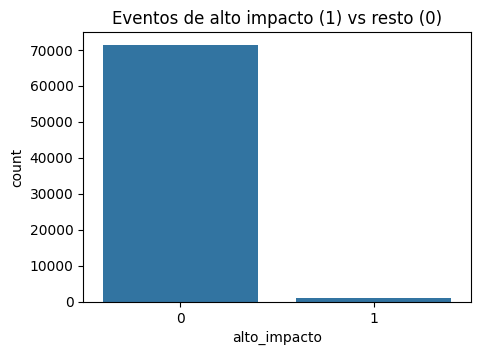

In [ ]:
conteo = df["alto_impacto"].value_counts()
print(conteo)
print()
print("Porcentaje de alto impacto:", round(df["alto_impacto"].mean() * 100, 2), "%")

print()
print("Con víctimas:", (df["victimas"] > 0).sum())
print("Con daño >= 1 millón USD:", (df["dano_total"] >= 1_000_000).sum())

plt.figure(figsize=(5, 3.5))
sns.countplot(x="alto_impacto", data=df)
plt.title("Eventos de alto impacto (1) vs resto (0)")
plt.show()

Hay 1,014 eventos de alto impacto de 72,360, es decir **1.40 %**. De esos, 779 eventos tienen víctimas y 281 tienen daño de al menos 1 millón de USD. Como se puede ver las clases están muy desbalanceadas. Un modelo que diga "ningún evento es de alto impacto" tendría 98.6 % de accuracy sin servir para nada, así que la accuracy no será una buena métrica.


## P2. Distribuciones: tipos de evento, daños y víctimas

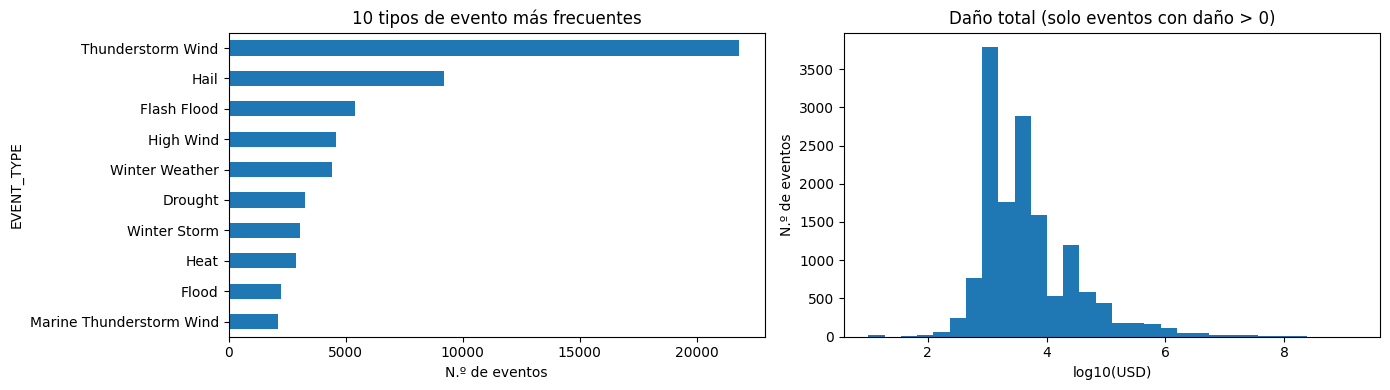

Eventos con daño > 0: 14718 de 72360
Daño total (USD) entre los eventos con daño > 0:
count    1.471800e+04
mean     3.241900e+05
std      1.371040e+07
min      1.000000e+01
25%      1.000000e+03
50%      3.000000e+03
75%      1.000000e+04
max      1.600000e+09
Name: dano_total, dtype: float64

Eventos con al menos una víctima: 779
Máximo de víctimas en un evento: 166


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["EVENT_TYPE"].value_counts().head(10).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("10 tipos de evento más frecuentes")
axes[0].set_xlabel("N.º de eventos")

con_dano = df.loc[df["dano_total"] > 0, "dano_total"]
axes[1].hist(np.log10(con_dano), bins=30)
axes[1].set_title("Daño total (solo eventos con daño > 0)")
axes[1].set_xlabel("log10(USD)")
axes[1].set_ylabel("N.º de eventos")

plt.tight_layout()
plt.show()

print("Eventos con daño > 0:", len(con_dano), "de", len(df))
print("Daño total (USD) entre los eventos con daño > 0:")
print(con_dano.describe().round(0))
print()
print("Eventos con al menos una víctima:", (df["victimas"] > 0).sum())
print("Máximo de víctimas en un evento:", df["victimas"].max())

### **Lo que muestran los datos**

* **Thunderstorm Wind** (21,807) y **Hail** (9,205) son los tipos de eventos más frecuentes, bastante por encima de los demás.

* Solo **14,718 eventos tienen algún daño registrado mayor que 0**, y la mediana del daño es de aproximadamente **3,000 USD**. En el gráfico con escala logarítmica se puede ver que los valores van desde daños de algunas decenas de dólares hasta **cientos de millones**.

* En cuanto a las víctimas, la mayoría de los eventos tienen **0 muertes o lesiones**, mientras que unos pocos llegan a tener decenas de personas afectadas. El máximo registrado es de **166 víctimas en un solo evento**.

### **Interpretación**

Los daños tienen una **distribución bastante sesgada**, ya que la mayoría de eventos tienen daños bajos o nulos, mientras que unos pocos concentran cantidades muy grandes.

Por eso, consideramos que tiene más sentido plantear el problema como una **clasificación de alto impacto (sí/no)** en lugar de intentar predecir directamente el monto exacto del daño. Además, los valores extremos no deberían eliminarse simplemente por ser muy altos, porque justamente podrían representar los eventos que queremos identificar como de alto impacto.


## P3. Alto impacto según el tipo de evento

                  n_eventos  n_alto_impacto   tasa
EVENT_TYPE                                        
Wildfire                350              79  0.226
Lightning               288              57  0.198
Tornado                1591             128  0.080
Heat                   2864             105  0.037
Excessive Heat         1439              45  0.031
Dust Storm              320              10  0.031
Lake-Effect Snow        163               4  0.025
Flash Flood            5393             118  0.022
Cold/Wind Chill        1065              20  0.019
Dense Fog               632              11  0.017


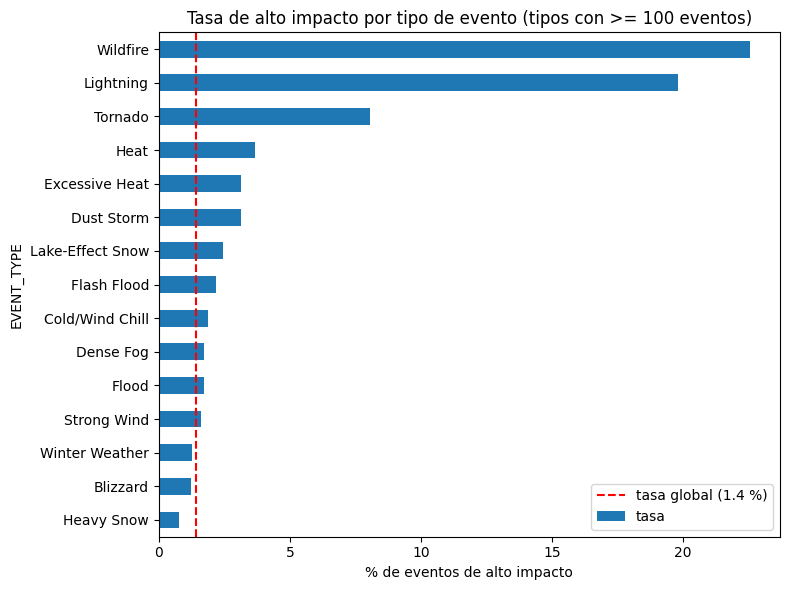

In [ ]:
por_tipo = df.groupby("EVENT_TYPE")["alto_impacto"].agg(["count", "sum", "mean"])
por_tipo.columns = ["n_eventos", "n_alto_impacto", "tasa"]
por_tipo = por_tipo[por_tipo["n_eventos"] >= 100]      # evitamos tipos con muy pocos casos

print(por_tipo.sort_values("tasa", ascending=False).head(10).round(3))

plt.figure(figsize=(8, 6))
(por_tipo["tasa"].sort_values().tail(15) * 100).plot(kind="barh")
plt.axvline(df["alto_impacto"].mean() * 100, color="red", linestyle="--", label="tasa global (1.4 %)")
plt.xlabel("% de eventos de alto impacto")
plt.title("Tasa de alto impacto por tipo de evento (tipos con >= 100 eventos)")
plt.legend()
plt.tight_layout()
plt.show()

**Lo que muestran los datos.** La tasa cambia muchísimo según el tipo: *Wildfire* 22.6 % (350 eventos),
*Lightning* 19.8 % (288) y *Tornado* 8.0 % (1,591) están muy por encima de la tasa global (1.4 %).
En el otro extremo, *Hail* tiene 0.18 % (17 de 9,205) y *Marine Thunderstorm Wind* 0.05 %.

**Interpretación del grupo.** El tipo de evento parece una de las variables más informativas.
Un modelo que solo use el tipo ya podría ser un baseline razonable, y el modelo "real" tendrá que
superarlo para justificarse. Ojo: los tipos con mucha tasa pero pocos eventos (como *Wildfire*) aportan menos positivos en total
que tipos frecuentes con tasa baja (como *Thunderstorm Wind*).

## P4. Alto impacto según el mes

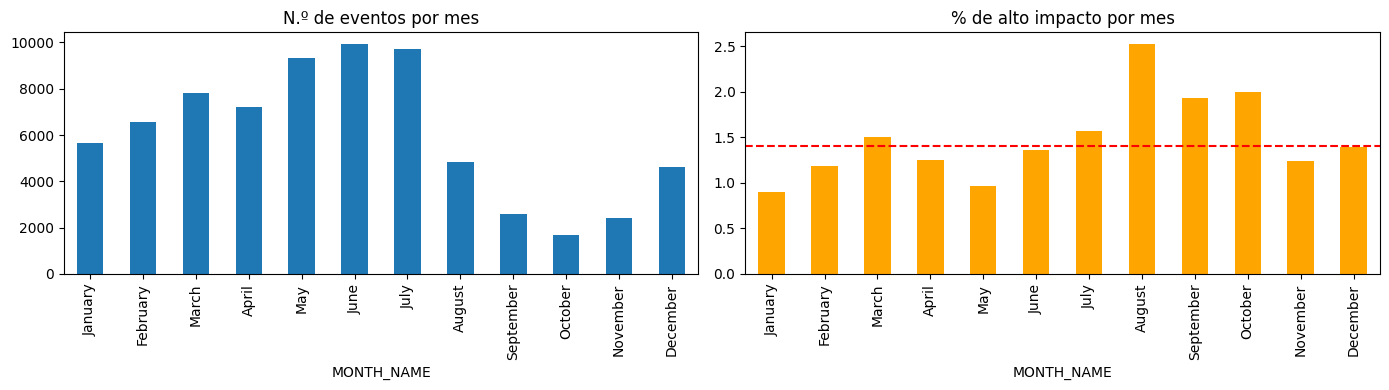

In [ ]:
orden_meses = ["January", "February", "March", "April", "May", "June", "July",
               "August", "September", "October", "November", "December"]

por_mes = df.groupby("MONTH_NAME")["alto_impacto"].agg(["count", "mean"]).reindex(orden_meses)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
por_mes["count"].plot(kind="bar", ax=axes[0])
axes[0].set_title("N.º de eventos por mes")

(por_mes["mean"] * 100).plot(kind="bar", ax=axes[1], color="orange")
axes[1].axhline(df["alto_impacto"].mean() * 100, color="red", linestyle="--")
axes[1].set_title("% de alto impacto por mes")

plt.tight_layout()
plt.show()

### **Lo que muestran los datos**

La mayor cantidad de eventos ocurre entre mayo y julio, con más de 9,300 eventos por mes.

Sin embargo, tener más eventos no significa necesariamente tener más eventos de alto impacto. La tasa de alto impacto es mayor en **agosto (2.5 %)** y **octubre (2.0 %)**, mientras que es menor en **enero (0.9 %)** y **mayo (1.0 %)**.

### **Interpretación**

El mes parece tener una relación más bien **débil con el objetivo**, ya que las diferencias en la tasa de alto impacto son relativamente pequeñas comparadas con las diferencias que vimos entre los tipos de evento.

También es posible que parte de esta relación se deba a los tipos de eventos que son más frecuentes en cada mes. Por ejemplo, algunos fenómenos pueden concentrarse en determinadas épocas del año, pero esto no lo hemos comprobado todavía.


## P5. Alto impacto según quién reporta el evento (`SOURCE`)

                           n_eventos  n_alto_impacto   tasa
SOURCE                                                     
County Official                  321             133  0.414
Park/Forest Service              337              56  0.166
NWS Storm Survey                1772             144  0.081
Broadcast Media                 2045             140  0.068
Fire Department/Rescue           952              42  0.044
Emergency Manager               6785             215  0.032
Law Enforcement                 2202              64  0.029
Official NWS Observations        827              11  0.013
State Official                  1287              13  0.010
Department of Highways          2267              21  0.009
Amateur Radio                    783               6  0.008
River/Stream Gage                676               5  0.007
911 Call Center                 4839              25  0.005
NWS Employee                     998               5  0.005
Social Media                    1003    

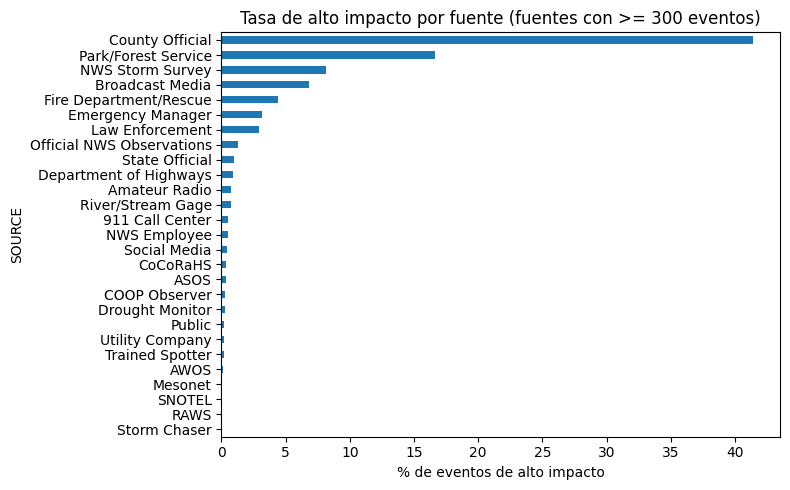

In [ ]:
por_fuente = df.groupby("SOURCE")["alto_impacto"].agg(["count", "sum", "mean"])
por_fuente.columns = ["n_eventos", "n_alto_impacto", "tasa"]
por_fuente = por_fuente[por_fuente["n_eventos"] >= 300].sort_values("tasa", ascending=False)

print(por_fuente.round(3))

plt.figure(figsize=(8, 5))
(por_fuente["tasa"].sort_values() * 100).plot(kind="barh")
plt.xlabel("% de eventos de alto impacto")
plt.title("Tasa de alto impacto por fuente (fuentes con >= 300 eventos)")
plt.tight_layout()
plt.show()

### **Lo que muestran los datos**

La tasa de alto impacto también cambia bastante según la fuente del reporte. **County Official** tiene una tasa de **41.4 %** (321 eventos), seguido de **Park/Forest Service** con **16.6 %**, **NWS Storm Survey** con **8.1 %** y **Broadcast Media** con **6.8 %**.

En cambio, algunas fuentes automáticas, como **RAWS**, **SNOTEL** y **Storm Chaser**, tienen una tasa de **0 %** en estos datos.

### **Interpretación**

Sin embargo, estos resultados pueden ser engañosos. Es posible que algunas fuentes, especialmente autoridades, encuestas del NWS o medios, aparezcan con mayor frecuencia **después de que ya ocurrió un evento importante o se reportaron daños o víctimas**.

Por eso, `SOURCE` podría estar relacionado con el impacto como consecuencia del evento y no como una característica que podamos conocer antes. Si usamos esta variable como predictor, el modelo podría obtener buenos resultados por una razón que no representa realmente una predicción anticipada.

Esto representa un posible problema de **data leakage**, por lo que debemos evaluarlo antes de incluir `SOURCE` en el modelo.

**Decisión (auditoría de variables, sección 4):** `SOURCE` se excluye como predictor, porque es la fuente que se asigna al documentar el evento y no está disponible en t₀.

## P6. Diferencias entre grupos: duración e intensidad

Duración (horas) por grupo:
                count   mean  50%     max
alto_impacto                             
0             71346.0  35.63  0.1  743.98
1              1014.0  38.23  2.0  743.98

Magnitud (nudos) en Thunderstorm Wind:
                count  mean   50%    max
alto_impacto                            
0             21664.0  53.8  52.0  109.0
1               143.0  62.2  56.0  104.0


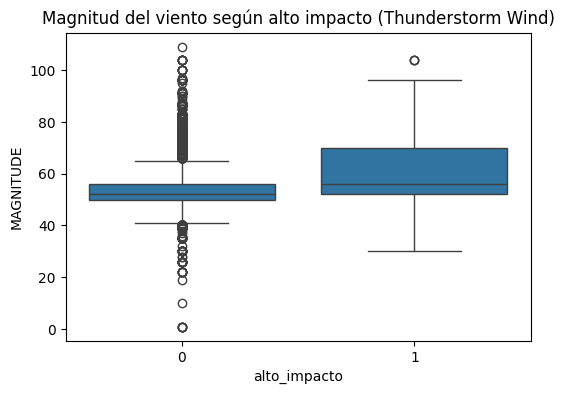

In [ ]:
inicio = pd.to_datetime(df["BEGIN_DATE_TIME"], format="%d-%b-%y %H:%M:%S", errors="coerce")
fin    = pd.to_datetime(df["END_DATE_TIME"],   format="%d-%b-%y %H:%M:%S", errors="coerce")
df["duracion_h"] = (fin - inicio).dt.total_seconds() / 3600

print("Duración (horas) por grupo:")
print(df.groupby("alto_impacto")["duracion_h"].describe()[["count", "mean", "50%", "max"]].round(2))

# La magnitud no se puede comparar entre tipos (nudos vs pulgadas), así que usamos un solo tipo
viento = df[df["EVENT_TYPE"] == "Thunderstorm Wind"]
print()
print("Magnitud (nudos) en Thunderstorm Wind:")
print(viento.groupby("alto_impacto")["MAGNITUDE"].describe()[["count", "mean", "50%", "max"]].round(1))

plt.figure(figsize=(6, 4))
sns.boxplot(x="alto_impacto", y="MAGNITUDE", data=viento)
plt.title("Magnitud del viento según alto impacto (Thunderstorm Wind)")
plt.show()

### **Lo que muestran los datos**

La duración también cambia entre los eventos normales y los de alto impacto. La duración mediana es de **0.1 horas** en los eventos normales, mientras que en los de alto impacto es de **2.0 horas**.

En **Thunderstorm Wind**, los eventos de alto impacto (143) tienen una magnitud mediana de **56 nudos**, frente a **52 nudos** en los demás eventos (21,664). Además, el promedio es de **62 nudos** frente a **54 nudos**, aunque también hay algunos valores bastante altos.

### **Interpretación**

En general, los eventos de alto impacto tienden a **durar más y presentar una mayor intensidad**, pero las distribuciones se traslapan bastante, como se puede ver en el boxplot. Por eso, la intensidad por sí sola **no parece suficiente para identificar un evento de alto impacto**.

Además, la duración depende bastante del tipo de evento. Por ejemplo, una sequía puede durar mucho más que un tornado, por lo que comparar la duración de todos los tipos de eventos directamente no es del todo limpio. Esto sugiere que, si se quiere comparar la duración, conviene hacerlo dentro de un mismo tipo de evento.

**Importante para el modelo:** la duración se calcula con la hora de fin (`END_DATE_TIME`), que solo se conoce cuando el evento ya terminó. Por eso la usamos en el EDA, pero no puede ser un predictor en t₀.

## P7. Patrones raros y anomalías

In [ ]:
print("Eventos con duración exacta 0 h:", (df["duracion_h"] == 0).sum(),
      f"({(df['duracion_h'] == 0).mean():.1%})")

print()
print("Tipos con mayor duración mediana (horas):")
print(df.groupby("EVENT_TYPE")["duracion_h"].median().sort_values(ascending=False).head(3).round(1))

print()
print("Los 5 eventos con mayor daño:")
df.nlargest(5, "dano_total")[["EVENT_TYPE", "STATE", "dano_total", "victimas"]]

Eventos con duración exacta 0 h: 27091 (37.4%)

Tipos con mayor duración mediana (horas):
EVENT_TYPE
Drought             720.0
Wildfire            124.6
Storm Surge/Tide     57.0
Name: duracion_h, dtype: float64

Los 5 eventos con mayor daño:


,EVENT_TYPE,STATE,dano_total,victimas
27385,Tornado,MISSOURI,1.600000e+09,42
58835,Flash Flood,ILLINOIS,2.300000e+08,0
65403,Flash Flood,TEXAS,2.000000e+08,61
67627,Flash Flood,ILLINOIS,2.000000e+08,0
50857,Flash Flood,TEXAS,1.050000e+08,0


In [ ]:
sin_coord = df["BEGIN_LAT"].isna()
print("Eventos sin coordenadas:", sin_coord.sum(), f"({sin_coord.mean():.1%})")
print()
print(pd.crosstab(df["CZ_TYPE"], sin_coord, normalize="index").round(3))

Eventos sin coordenadas: 28443 (39.3%)

BEGIN_LAT  False  True 
CZ_TYPE                
C          0.997  0.003
Z          0.078  0.922


### **Lo que muestran los datos**

* El **37.4 % de los eventos tiene una duración de 0 horas**, es decir, la hora de inicio y fin es la misma. En cambio, las **sequías** son los eventos que duran más, con una mediana de aproximadamente **720 horas**.

* El evento con mayor daño registrado es un **tornado en Missouri**, con aproximadamente **1,600 millones de USD** en daños y **42 víctimas**. Después aparecen varios casos de **Flash Flood** en Illinois y Texas con daños bastante altos.

* El **39.3 % de los eventos no tiene coordenadas**. Esto está relacionado con el tipo de zona: en las zonas de pronóstico (`CZ_TYPE = Z`) solo el **7.8 %** tiene coordenadas, mientras que en las zonas por condado (`CZ_TYPE = C`) las tienen casi todos (**99.7 %**).

### **Interpretación**

Los eventos con duración de 0 horas parecen corresponder a **eventos puntuales**, como un reporte de granizo, por lo que no necesariamente representan errores en los datos.

Los valores extremos de daño también tienen sentido según el tipo de evento, así que **no deberíamos eliminarlos simplemente por ser valores muy altos**, ya que justamente pueden corresponder a los eventos que queremos identificar como de alto impacto.

Por otro lado, la falta de coordenadas no parece ser aleatoria, sino que está relacionada con el tipo de zona. Por eso, si usamos latitud y longitud directamente en el modelo, podríamos terminar perdiendo una parte importante de los eventos o introduciendo algún sesgo. Tendremos que considerar esto al momento de preparar estas variables.


## Resumen del EDA

| # | Hallazgo (datos) | Decisión que condiciona |
|---|------------------|-------------------------|
| 1 | Solo 1.4 % de eventos son de alto impacto | No usar accuracy; usar recall / precisión; cuidar la separación train/test |
| 2 | Daños con cola muy larga | Clasificar en vez de predecir montos; no borrar extremos |
| 3 | El tipo de evento separa mucho las clases | Usarlo como variable clave y como baseline |
| 4 | Mes con efecto débil | Variable secundaria |
| 5 | `SOURCE` muy asociada al objetivo, pero posiblemente consecuencia del impacto | Se excluye como predictor: no está disponible en t₀ (ver auditoría de variables) |
| 6 | Más duración e intensidad en eventos graves, con traslape | La duración queda solo para el EDA (necesita la hora de fin, posterior a t₀); la magnitud se usará separada por unidad (viento / granizo) |
| 7 | 39 % sin coordenadas, no al azar | No depender de latitud/longitud; usar estado / tipo de zona |

# 4. Calidad y preparación de datos

## Valores faltantes

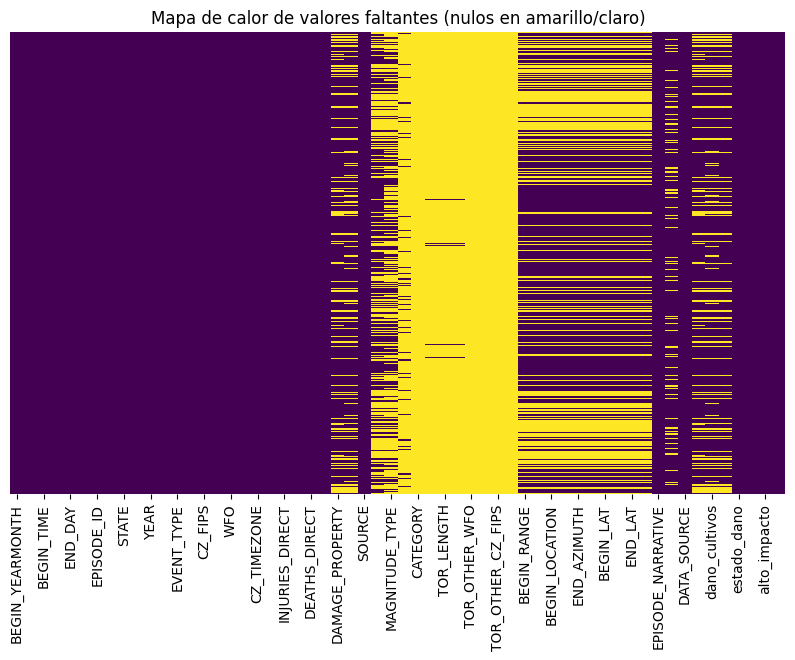

In [ ]:
#valores faltantes en heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa de calor de valores faltantes (nulos en amarillo/claro)")
plt.show()

In [ ]:
# Calcular el porcentaje de valores nulos por columna
porcentaje_nulos = (df.isna().sum() / len(df)) * 100
porcentaje_nulos = porcentaje_nulos.sort_values(ascending=False)

# Convertir a DataFrame para una visualización más limpia
porcentaje_nulos_df = porcentaje_nulos.to_frame(name="% de Nulos")
display(porcentaje_nulos_df.head(25))

,% de Nulos
CATEGORY,100.000000
TOR_OTHER_CZ_FIPS,99.610282
TOR_OTHER_WFO,99.610282
TOR_OTHER_CZ_STATE,99.610282
TOR_OTHER_CZ_NAME,99.610282
TOR_WIDTH,97.801271
TOR_LENGTH,97.801271
TOR_F_SCALE,97.801271
FLOOD_CAUSE,89.197070
MAGNITUDE_TYPE,58.898563


## Duplicados

In [ ]:
print("Filas duplicadas exactas:", df.duplicated().sum())
print("EVENT_ID repetidos:", df["EVENT_ID"].duplicated().sum())
print("Eventos únicos:", df["EVENT_ID"].nunique(), "de", len(df))

Filas duplicadas exactas: 0
EVENT_ID repetidos: 0
Eventos únicos: 72360 de 72360


In [ ]:
# ¿Hay filas que repiten TODO menos el EVENT_ID?
cols_sin_id = [c for c in df.columns if c != "EVENT_ID"]
posible_dup = df.duplicated(subset=cols_sin_id, keep="first")

print("Filas que repiten todas las columnas menos EVENT_ID:", posible_dup.sum(),
      f"({posible_dup.mean():.2%})")
print("De ellas, de alto impacto:", df.loc[posible_dup, "alto_impacto"].sum())
print()
print("Tipos de evento más repetidos:")
print(df.loc[posible_dup, "EVENT_TYPE"].value_counts().head(5))

Filas que repiten todas las columnas menos EVENT_ID: 79 (0.11%)
De ellas, de alto impacto: 0

Tipos de evento más repetidos:
EVENT_TYPE
Thunderstorm Wind    32
Hail                 13
Flash Flood          10
Winter Storm          6
Winter Weather        3
Name: count, dtype: int64


In [ ]:
# Ejemplo de pares repetidos
pares = df[df.duplicated(subset=cols_sin_id, keep=False)].sort_values(["EPISODE_ID", "BEGIN_DATE_TIME", "CZ_NAME"])
pares[["EVENT_ID", "EPISODE_ID", "EVENT_TYPE", "STATE", "CZ_NAME", "BEGIN_DATE_TIME", "MAGNITUDE"]].head(8)

,EVENT_ID,EPISODE_ID,EVENT_TYPE,STATE,CZ_NAME,BEGIN_DATE_TIME,MAGNITUDE
12390,1222372,197568,Winter Storm,MISSOURI,BATES,04-JAN-25 12:00:00,NaN
14670,1222371,197568,Winter Storm,MISSOURI,BATES,04-JAN-25 12:00:00,NaN
12389,1222370,197568,Winter Storm,MISSOURI,CASS,04-JAN-25 12:00:00,NaN
14469,1222368,197568,Winter Storm,MISSOURI,CASS,04-JAN-25 12:00:00,NaN
12020,1222152,197568,Blizzard,MISSOURI,PLATTE,05-JAN-25 03:00:00,NaN
14277,1222151,197568,Blizzard,MISSOURI,PLATTE,05-JAN-25 03:00:00,NaN
15637,1227352,198488,Strong Wind,CALIFORNIA,KAISER TO RODGERS RIDGE,13-FEB-25 12:37:00,43.0
15840,1227353,198488,Strong Wind,CALIFORNIA,KAISER TO RODGERS RIDGE,13-FEB-25 12:37:00,43.0


In [ ]:
# Los eventos de un mismo episodio comparten sistema meteorológico
por_episodio = df.groupby("EPISODE_ID").size()
print("Episodios distintos:", len(por_episodio))
print("Eventos por episodio -> mediana:", por_episodio.median(), "| máximo:", por_episodio.max())

Episodios distintos: 9846
Eventos por episodio -> mediana: 3.0 | máximo: 412


* No hay **filas duplicadas exactas** (0) ni **`EVENT_ID` repetidos**. Es decir, los 72,360 eventos tienen un identificador único.

* Sin embargo, al comparar todas las columnas **excepto `EVENT_ID`**, encontramos **79 filas (0.11 %)** que son iguales a otra fila del mismo episodio: tienen el mismo tipo de evento, condado o zona, hora y demás valores. La mayoría son *Thunderstorm Wind* (32), *Hail* (13) y *Flash Flood* (10). **Ninguna corresponde a un evento de alto impacto.**

* Los 9,846 episodios tienen una mediana de 3 eventos y un máximo de 412. Esto muestra que varios eventos pueden pertenecer al mismo sistema de tormentas.

Un duplicado exacto y un conflicto de clave no son lo mismo. En este caso no tenemos duplicados exactos, así que no eliminamos registros por ese motivo. Las 79 filas encontradas **parecen registros repetidos**, pero no podemos asegurar que realmente lo sean, ya que podrían ser reportes distintos que coincidentemente tienen los mismos valores.

Como representan solo el **0.11 %** de los datos y ninguno es de alto impacto, decidimos **marcarlos con la bandera `posible_duplicado` en lugar de eliminarlos**.

Además, como los eventos de un mismo episodio pueden ser bastante similares entre sí, al momento de separar los datos en train y test tendremos que **agrupar por `EPISODE_ID`** para evitar que eventos del mismo episodio queden en ambos conjuntos y terminen filtrando información entre ellos.



## Tipos de datos

In [ ]:
print(df.dtypes.value_counts())

revisar = ["BEGIN_DATE_TIME", "END_DATE_TIME", "BEGIN_TIME", "DAMAGE_PROPERTY", "DAMAGE_CROPS",
           "EVENT_ID", "EPISODE_ID", "STATE_FIPS", "CZ_FIPS", "YEAR", "CATEGORY"]

pd.DataFrame({
    "tipo_actual": df[revisar].dtypes.astype(str),
    "ejemplo": df[revisar].iloc[0].astype(str)
})

object     26
int64      17
float64    15
Name: count, dtype: int64


,tipo_actual,ejemplo
BEGIN_DATE_TIME,object,31-MAR-25 11:04:00
END_DATE_TIME,object,31-MAR-25 11:06:00
BEGIN_TIME,int64,1104
DAMAGE_PROPERTY,object,1.00K
DAMAGE_CROPS,object,nan
EVENT_ID,int64,1252415
EPISODE_ID,int64,201366
STATE_FIPS,int64,13
CZ_FIPS,int64,45
YEAR,int64,2025


In [ ]:
# Convertimos las fechas a datetime (columnas nuevas, no tocamos las originales)
df["inicio"] = pd.to_datetime(df["BEGIN_DATE_TIME"], format="%d-%b-%y %H:%M:%S", errors="coerce")
df["fin"]    = pd.to_datetime(df["END_DATE_TIME"],   format="%d-%b-%y %H:%M:%S", errors="coerce")

print("Fechas de inicio que no se pudieron convertir:", df["inicio"].isna().sum())
print("Fechas de fin que no se pudieron convertir:", df["fin"].isna().sum())
print("Tipo nuevo:", df["inicio"].dtype)

df[["BEGIN_DATE_TIME", "inicio", "END_DATE_TIME", "fin"]].head(3)

Fechas de inicio que no se pudieron convertir: 0
Fechas de fin que no se pudieron convertir: 0
Tipo nuevo: datetime64[ns]


,BEGIN_DATE_TIME,inicio,END_DATE_TIME,fin
0,31-MAR-25 11:04:00,2025-03-31 11:04:00,31-MAR-25 11:06:00,2025-03-31 11:06:00
1,30-MAR-25 15:52:00,2025-03-30 15:52:00,30-MAR-25 15:55:00,2025-03-30 15:55:00
2,05-JAN-25 18:00:00,2025-01-05 18:00:00,06-JAN-25 22:27:00,2025-01-06 22:27:00


In [ ]:
# Validamos la conversión de los daños que hicimos en la sección 3.0
for col, nueva in [("DAMAGE_PROPERTY", "dano_propiedad"), ("DAMAGE_CROPS", "dano_cultivos")]:
    sufijos = df[col].dropna().str[-1].value_counts()
    sin_convertir = (df[col].notna() & df[nueva].isna()).sum()
    print(f"{col}: sufijos -> {sufijos.to_dict()} | valores sin convertir: {sin_convertir}")

DAMAGE_PROPERTY: sufijos -> {'K': 55582, 'M': 259, '0': 119, 'B': 1} | valores sin convertir: 0
DAMAGE_CROPS: sufijos -> {'K': 55075, '0': 119, 'M': 20} | valores sin convertir: 0


### **Lo que muestran los datos**

Contando las 51 columnas originales y las 7 que creamos en la sección 3, hay 26 columnas de texto, 17 enteras y 15 decimales. Los problemas de tipo que encontramos son:

| Columna | Tipo actual | Problema | Decisión |
|---------|-------------|----------|----------|
| `BEGIN_DATE_TIME`, `END_DATE_TIME` | texto | fecha escrita como `31-MAR-25 11:04:00` | convertir a `datetime` (`inicio`, `fin`) |
| `DAMAGE_PROPERTY`, `DAMAGE_CROPS` | texto | monto con sufijo K, M o B (`1.00K`) | convertir a número (ya hecho en 3.0) |
| `EVENT_ID`, `EPISODE_ID`, `STATE_FIPS`, `CZ_FIPS` | entero | son códigos, no cantidades | convertir a texto |
| `BEGIN_TIME`, `END_TIME` | entero | hora como número HHMM (1104 = 11:04) | no se usa; se trabaja con `inicio` y `fin` |
| `MAGNITUDE` | decimal | mezcla nudos (viento) y pulgadas (granizo) | separar en `viento_kt` y `granizo_in` (ver abajo) |
| `CATEGORY` | decimal | está vacía en todas las filas | eliminar |
| `YEAR` | entero | siempre vale 2025 | eliminar |

### **Validación**

* Las **72,360 fechas** de inicio y de fin se convirtieron sin ningún error.
* Todos los daños terminan en K, M o B, o son `"0"` (119 casos sin sufijo, que son ceros). **No quedó ningún valor sin convertir.**

### Magnitud: una sola columna con dos unidades

In [ ]:
# ¿En qué tipos de evento hay magnitud y con qué unidad?
con_mag = df[df["MAGNITUDE"].notna()]
print("Eventos con magnitud:", len(con_mag), "de", len(df),
      "| tipos de evento con magnitud:", con_mag["EVENT_TYPE"].nunique(), "de", df["EVENT_TYPE"].nunique())

tabla_mag = con_mag.groupby("EVENT_TYPE").agg(
    n=("MAGNITUDE", "size"),
    minimo=("MAGNITUDE", "min"),
    mediana=("MAGNITUDE", "median"),
    maximo=("MAGNITUDE", "max"),
    MAGNITUDE_TYPE=("MAGNITUDE_TYPE", lambda s: ", ".join(sorted(s.dropna().unique())) or "-"))
tabla_mag.sort_values("n", ascending=False)

Eventos con magnitud: 38971 de 72360 | tipos de evento con magnitud: 8 de 48


,n,minimo,mediana,maximo,MAGNITUDE_TYPE
EVENT_TYPE,,,,,
Thunderstorm Wind,21807,1.00,52.0,109.0,"EG, ES, MG"
Hail,9205,0.25,1.0,6.0,-
High Wind,4603,26.00,54.0,143.0,"EG, ES, MG, MS"
Marine Thunderstorm Wind,2126,34.00,38.0,72.0,"EG, MG"
Strong Wind,1116,13.00,40.0,49.0,"EG, ES, MG, MS"
Marine High Wind,83,48.00,52.0,66.0,"EG, MG"
Marine Hail,25,0.75,1.0,2.0,-
Marine Strong Wind,6,30.00,43.0,45.0,"EG, MG"


### **Lo que muestran los datos**

* Solo **8 de los 48** tipos de evento tienen magnitud (38,971 eventos). En los 6 tipos de viento está en **nudos**
  (medianas entre 38 y 54) y en *Hail* y *Marine Hail* está en **pulgadas** de diámetro (de 0.25 a 6).
  En los otros 40 tipos la columna está vacía porque no aplica: por ejemplo, un tornado o una inundación no tienen valor en este campo.
* `MAGNITUDE_TYPE` solo existe para viento (EG = ráfaga estimada, ES = viento sostenido estimado, MG = ráfaga medida,
  MS = viento sostenido medido, según NOAA); en granizo está vacío.

### **Decisión**

No usamos `MAGNITUDE` tal cual: un valor de 1.0 puede ser una pulgada de granizo o 1 nudo de viento. En las transformaciones
creamos `viento_kt` (solo tipos de viento) y `granizo_in` (solo granizo). En los demás eventos quedan vacías, lo que significa
"no aplica", no un dato perdido. `MAGNITUDE_TYPE` se conserva tal cual.

## Categorías inconsistentes

In [ ]:
cols_cat = ["STATE", "EVENT_TYPE", "SOURCE", "CZ_TYPE", "MONTH_NAME", "WFO",
            "CZ_TIMEZONE", "MAGNITUDE_TYPE", "TOR_F_SCALE", "CZ_NAME"]

filas = []
for col in cols_cat:
    s = df[col].dropna().astype(str)
    normal = s.str.strip().str.upper()          # sin espacios y en mayúsculas
    filas.append({
        "columna": col,
        "categorias": s.nunique(),
        "tras_normalizar": normal.nunique(),
        "con_espacios_sobrantes": (s != s.str.strip()).sum()
    })

pd.DataFrame(filas)

,columna,categorias,tras_normalizar,con_espacios_sobrantes
0,STATE,68,68,0
1,EVENT_TYPE,48,48,0
2,SOURCE,42,42,0
3,CZ_TYPE,2,2,0
4,MONTH_NAME,12,12,0
5,WFO,123,123,0
6,CZ_TIMEZONE,11,11,0
7,MAGNITUDE_TYPE,4,4,0
8,TOR_F_SCALE,7,7,0
9,CZ_NAME,3412,3412,0


In [ ]:
# CZ_NAME: probamos quitando signos de puntuación (apóstrofes, puntos)
nombres = df["CZ_NAME"].astype(str)
sin_signos = nombres.str.upper().str.replace(r"[^A-Z0-9 ]", "", regex=True)

tabla = pd.DataFrame({"original": nombres, "sin_signos": sin_signos}).drop_duplicates()
variantes = tabla.groupby("sin_signos")["original"].nunique()
variantes = variantes[variantes > 1]

print("Nombres que se escriben de dos formas:", len(variantes))
df[df["CZ_NAME"].isin(tabla[tabla["sin_signos"].isin(variantes.index)]["original"])] \
    .groupby(["CZ_NAME", "STATE", "CZ_TYPE"]).size()

Nombres que se escriben de dos formas: 2


,,,0
CZ_NAME,STATE,CZ_TYPE,
PRINCE GEORGE'S,MARYLAND,C,35
PRINCE GEORGES,MARYLAND,Z,13
QUEEN ANNE'S,MARYLAND,C,15
QUEEN ANNES,MARYLAND,Z,10


In [ ]:
print(df["CZ_TIMEZONE"].value_counts())
print()
print("Eventos con CZ_TIMEZONE poco común:")
display(df[df["CZ_TIMEZONE"].isin(["EDT-4", "PDT-7", "GST10"])].groupby(["CZ_TIMEZONE", "STATE"]).size())

# ¿En qué meses aparecen EDT-4 y PDT-7? (en EE. UU. no hay horario de verano en enero, febrero ni diciembre)
verano = df[df["CZ_TIMEZONE"].isin(["EDT-4", "PDT-7"])]
pd.crosstab(verano["CZ_TIMEZONE"], verano["inicio"].dt.month.rename("mes"))

CZ_TIMEZONE
CST-6     35400
EST-5     24782
MST-7      8601
PST-8      2578
AST-4       454
AKST-9      253
HST-10      126
SST-11       93
GST10        34
PDT-7        30
EDT-4         9
Name: count, dtype: int64

Eventos con CZ_TIMEZONE poco común:


CZ_TIMEZONE  STATE      
EDT-4        FLORIDA         9
GST10        GUAM           33
             GUAM WATERS     1
PDT-7        CALIFORNIA     30
dtype: int64

mes,1,2,5,6,7,8,9,10,11,12
CZ_TIMEZONE,,,,,,,,,,
EDT-4,2,0,1,0,0,0,1,5,0,0
PDT-7,3,8,0,1,2,6,0,0,8,2


In [ ]:
# STATE mezcla estados con zonas marítimas y lagos
zonas_no_estado = ["ATLANTIC NORTH", "ATLANTIC SOUTH", "GULF OF MEXICO", "E PACIFIC", "GULF OF ALASKA",
                   "LAKE HURON", "LAKE MICHIGAN", "LAKE SUPERIOR", "LAKE ERIE", "LAKE ONTARIO",
                   "LAKE ST CLAIR", "ST LAWRENCE R", "GUAM WATERS"]

df["es_zona_marina"] = df["STATE"].isin(zonas_no_estado).astype(int)

print("Valores de STATE:", df["STATE"].nunique())
print("Eventos en zonas marítimas o lagos:", df["es_zona_marina"].sum())
print()
print(df[df["es_zona_marina"] == 1]["STATE"].value_counts().head(5))

Valores de STATE: 68
Eventos en zonas marítimas o lagos: 2410

STATE
ATLANTIC NORTH    763
GULF OF MEXICO    654
ATLANTIC SOUTH    596
LAKE MICHIGAN     154
LAKE SUPERIOR      82
Name: count, dtype: int64


In [ ]:
# Tipos de evento con muy pocos casos
conteo_tipos = df["EVENT_TYPE"].value_counts()
pocos = conteo_tipos[conteo_tipos < 50]

print(len(pocos), "tipos con menos de 50 eventos; en total suman", pocos.sum(), "eventos")
pocos

15 tipos con menos de 50 eventos; en total suman 158 eventos


,count
EVENT_TYPE,
Avalanche,34
Marine Hail,25
Marine Tropical Storm,18
Sneakerwave,15
Sleet,13
Freezing Fog,11
Tropical Storm,10
Tsunami,10
Marine Strong Wind,6


* En las 10 columnas categóricas revisadas **no encontramos espacios sobrantes ni diferencias entre mayúsculas y minúsculas**. Al normalizarlas, la cantidad de categorías se mantiene igual.

* En `CZ_NAME` encontramos **2 parejas de nombres que solo se diferencian por el apóstrofe**, ambas en Maryland: *PRINCE GEORGE'S* (tipo condado, 35 eventos) y *PRINCE GEORGES* (tipo zona, 13), y *QUEEN ANNE'S* (15) y *QUEEN ANNES* (10). En cada pareja, una versión es un condado (C) y la otra una zona de pronóstico (Z), que son tipos de zona distintos. Por eso **no la consideramos una inconsistencia confirmada**: pueden ser dos unidades diferentes, cada una con su propio nombre.

* `CZ_TIMEZONE` tiene 11 valores. La mayoría siguen el formato `CST-6`, pero también aparecen 30 eventos de California con `PDT-7` y 9 de Florida con `EDT-4`, que son etiquetas de horario de verano. Sin embargo, aparecen incluso en enero, febrero y diciembre, cuando no hay horario de verano, y NOAA indica que las horas se registran normalmente en hora local estándar. `GST10` (Guam) no lleva guion porque Guam está al este de Greenwich (UTC+10); no es un error.

* `STATE` tiene 68 valores, pero **13 de ellos no corresponden a estados**, sino a zonas marítimas y lagos, como *ATLANTIC NORTH*, *GULF OF MEXICO* y *LAKE MICHIGAN*. En total, estos casos representan **2,410 eventos**.

* Hay **15 tipos de evento con menos de 50 casos**, que en conjunto representan 158 eventos. Por ejemplo, *Lakeshore Flood* aparece solo 1 vez y *Seiche* 2 veces.

### **Decisión**

* `CZ_NAME`: se conserva tal como viene, sin normalizar los nombres. (`CZ_NAME` no se usará como predictor; ver auditoría de variables.)

* `CZ_TIMEZONE`: **no** unificamos `EDT-4` con `EST-5` ni `PDT-7` con `PST-8`, porque no sabemos si en esos 39 eventos la hora está en horario de verano o si la etiqueta está mal; cambiar solo la etiqueta podría correr la hora en 1 h. Conservamos `CZ_TIMEZONE` original y creamos `region_horaria` (Este, Centro, Montaña, Pacífico, etc.), que no pretende indicar un desfase exacto. Las horas se mantienen como vienen.

* `STATE`: no se modifica, pero se crea la bandera `es_zona_marina` para identificar estos casos y evaluar más adelante si es necesario tratarlos de forma diferente.

* Los tipos de evento con pocos casos **no se agrupan todavía**. Esto se decidirá durante el modelamiento usando únicamente el conjunto de entrenamiento. Por ejemplo, podrían agruparse como `"Otros"`, pero hacerlo desde ahora podría usar información del conjunto de test.

## Outliers o valores extremos

In [ ]:
def resumen_iqr(serie, nombre):
    serie = serie.dropna()
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    lim_inf = q1 - 1.5 * iqr
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return {"variable": nombre, "n": len(serie), "mediana": round(serie.median(), 2),
            "máximo": round(serie.max(), 2), "límite_sup": round(lim_sup, 2),
            "n_outliers": n_out, "% outliers": round(n_out / len(serie) * 100, 1)}

tornados = df[df["EVENT_TYPE"] == "Tornado"]

tabla_out = pd.DataFrame([
    resumen_iqr(df.loc[df["dano_total"] > 0, "dano_total"], "daño total USD (solo > 0)"),
    resumen_iqr(df.loc[df["victimas"] > 0, "victimas"], "víctimas (solo > 0)"),
    resumen_iqr(df["duracion_h"], "duración (horas)"),
    resumen_iqr(df.loc[df["EVENT_TYPE"] == "Thunderstorm Wind", "MAGNITUDE"], "viento Thunderstorm Wind (nudos)"),
    resumen_iqr(df.loc[df["EVENT_TYPE"] == "Hail", "MAGNITUDE"], "granizo (pulgadas)"),
    resumen_iqr(tornados["TOR_LENGTH"], "largo del tornado (millas)"),
    resumen_iqr(tornados["TOR_WIDTH"], "ancho del tornado (yardas)"),
]).set_index("variable")

tabla_out

,n,mediana,máximo,límite_sup,n_outliers,% outliers
variable,,,,,,
daño total USD (solo > 0),14718,3000.00,1.600000e+09,23500.00,2467,16.8
víctimas (solo > 0),779,1.00,1.660000e+02,3.50,108,13.9
duración (horas),72360,0.10,7.439800e+02,23.67,9522,13.2
viento Thunderstorm Wind (nudos),21807,52.00,1.090000e+02,65.00,1369,6.3
granizo (pulgadas),9205,1.00,6.000000e+00,2.25,531,5.8
largo del tornado (millas),1591,2.39,3.527000e+01,12.51,98,6.2
ancho del tornado (yardas),1591,100.00,3.000000e+03,675.00,148,9.3


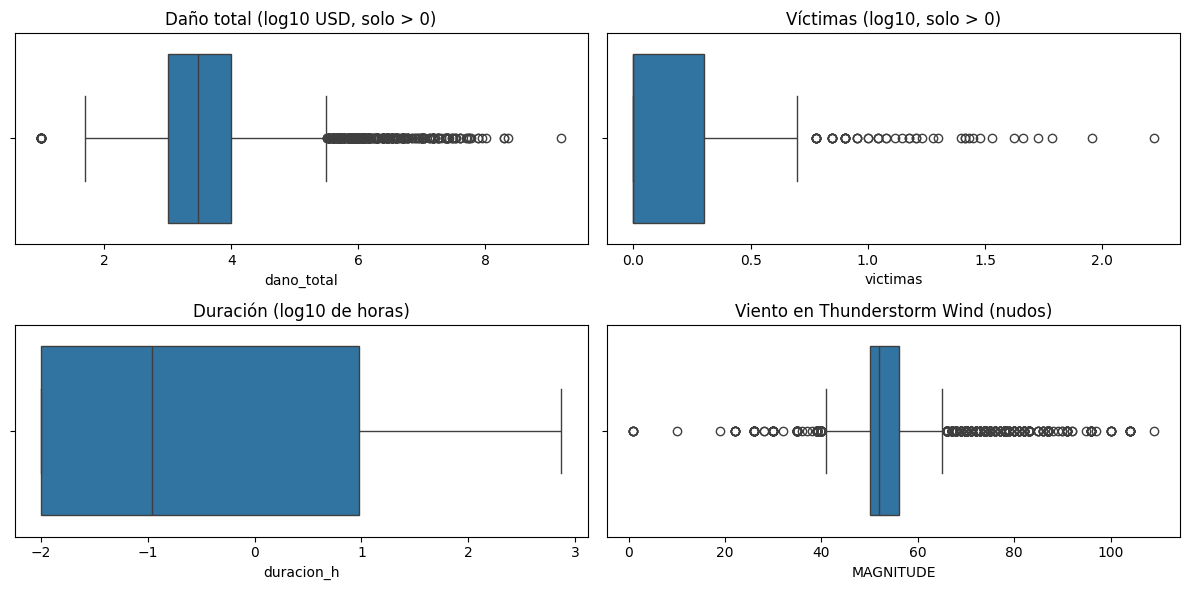

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

sns.boxplot(x=np.log10(df.loc[df["dano_total"] > 0, "dano_total"]), ax=axes[0, 0])
axes[0, 0].set_title("Daño total (log10 USD, solo > 0)")

sns.boxplot(x=np.log10(df.loc[df["victimas"] > 0, "victimas"]), ax=axes[0, 1])
axes[0, 1].set_title("Víctimas (log10, solo > 0)")

sns.boxplot(x=np.log10(df["duracion_h"] + 0.01), ax=axes[1, 0])
axes[1, 0].set_title("Duración (log10 de horas)")

sns.boxplot(x=df.loc[df["EVENT_TYPE"] == "Thunderstorm Wind", "MAGNITUDE"], ax=axes[1, 1])
axes[1, 1].set_title("Viento en Thunderstorm Wind (nudos)")

plt.tight_layout()
plt.show()

In [ ]:
# ¿Los extremos son errores o eventos reales? Miramos los 3 mayores daños
top = df.nlargest(3, "dano_total")
print(top[["EVENT_TYPE", "STATE", "BEGIN_DATE_TIME", "dano_total", "victimas"]])
print()
for i, fila in top.iterrows():
    print(fila["EVENT_TYPE"], "-", fila["STATE"], ":", str(fila["EVENT_NARRATIVE"])[:170], "...")
    print()

        EVENT_TYPE     STATE     BEGIN_DATE_TIME    dano_total  victimas
27385      Tornado  MISSOURI  16-MAY-25 13:42:00  1.600000e+09        42
58835  Flash Flood  ILLINOIS  17-AUG-25 01:30:00  2.300000e+08         0
65403  Flash Flood     TEXAS  04-JUL-25 03:00:00  2.000000e+08        61

Tornado - MISSOURI : The tornado was its widest and strongest in St. Louis City. After it crossed into the City, the tornado caused major tree and structural damage in and around Forest Park  ...

Flash Flood - ILLINOIS : Roughly 40,000 structures sustained flood damage around the city of Chicago. The greatest impacts were felt across the southwest side near and east of Midway Airport, but ...

Flash Flood - TEXAS : There was catastrophic and deadly flash flooding along the South Fork Guadalupe River after around ten inches of rain fell in approximately four hours. On Hwy 39 the debr ...



In [ ]:
# ¿Qué relación tienen los outliers con el alto impacto?
q1, q3 = df.loc[df["dano_total"] > 0, "dano_total"].quantile([0.25, 0.75])
lim_dano = q3 + 1.5 * (q3 - q1)

extremos_dano = df[df["dano_total"] > lim_dano]
print("Eventos con daño sobre", round(lim_dano), "USD:", len(extremos_dano))
print("De ellos, de alto impacto:", extremos_dano["alto_impacto"].sum())
print()

print("Los 5 eventos con más víctimas:")
df.nlargest(5, "victimas")[["EVENT_TYPE", "STATE", "BEGIN_DATE_TIME", "victimas"]]

Eventos con daño sobre 23500 USD: 2467
De ellos, de alto impacto: 382

Los 5 eventos con más víctimas:


,EVENT_TYPE,STATE,BEGIN_DATE_TIME,victimas
40603,Excessive Heat,NEW JERSEY,23-JUN-25 09:00:00,166
55723,Excessive Heat,MISSOURI,26-JUL-25 14:30:00,90
65403,Flash Flood,TEXAS,04-JUL-25 03:00:00,61
1834,Dust Storm,KANSAS,14-MAR-25 13:00:00,53
65607,Flash Flood,TEXAS,04-JUL-25 03:00:00,46




* Con la regla del IQR, casi todas las variables tienen valores que se consideran outliers: **2,467 eventos** tienen un daño mayor a 23,500 USD (16.8 % de los eventos que tienen daño), **108** tienen más de 3.5 víctimas, **9,522** tienen una duración de más de aproximadamente 24 horas y **1,369** presentan valores de viento fuera de lo normal dentro de *Thunderstorm Wind*.

* El porcentaje de outliers es relativamente alto porque las distribuciones son bastante asimétricas. Por ejemplo, la mediana del daño es de solo 3,000 USD, pero el máximo llega hasta **1,600 millones de USD**.

* Los valores más extremos **no parecen ser errores**. Al revisar las narrativas, el mayor daño corresponde al **tornado de St. Louis (Missouri)**, seguido por las inundaciones de **Chicago** y la **inundación del río Guadalupe en Texas**, que dejó 61 víctimas. El evento con mayor cantidad de víctimas corresponde a un caso de calor extremo en Nueva Jersey, con 166 víctimas.

* De los 2,467 eventos con daño considerado extremo, **382 son de alto impacto**. En el caso de las víctimas, los 108 outliers también son eventos de alto impacto, ya que la presencia de víctimas forma parte de la definición de esta clase.

* También encontramos valores altos en otras variables, como granizo de hasta **6 pulgadas**, viento de hasta **109 nudos** y un tornado con un ancho máximo de **3,000 yardas**. Aunque son valores extremos, siguen siendo posibles para este tipo de eventos.

### **Decisión**

**No eliminamos ni recortamos ningún outlier.** Los valores extremos corresponden a eventos reales y, justamente, son los casos que nos interesa detectar. Además, que un valor sea estadísticamente raro según el IQR no significa que sea un error.

Para el modelo trabajaremos principalmente con la variable `alto_impacto` (sí/no) en lugar de intentar predecir directamente el monto exacto del daño. Si más adelante necesitamos usar variables como daño o duración como variables numéricas, podemos aplicar una **transformación logarítmica** para reducir su asimetría en lugar de eliminar los valores extremos.


## Reglas lógicas o de negocio

In [ ]:
reglas = {
    "Fin del evento anterior al inicio": (df["fin"] < df["inicio"]).sum(),
    "Muertes o heridos negativos": (df[["DEATHS_DIRECT", "DEATHS_INDIRECT", "INJURIES_DIRECT", "INJURIES_INDIRECT"]] < 0).sum().sum(),
    "Daños negativos": (df["dano_total"] < 0).sum(),
    "Año distinto de 2025": (df["YEAR"] != 2025).sum(),
    "MONTH_NAME distinto del mes de la fecha": (df["inicio"].dt.month_name() != df["MONTH_NAME"]).sum(),
    "BEGIN_TIME distinto de la hora de la fecha": (df["inicio"].dt.hour != df["BEGIN_TIME"] // 100).sum(),
    "Escala de tornado en eventos que no son tornado": ((df["EVENT_TYPE"] != "Tornado") & df["TOR_F_SCALE"].notna()).sum(),
    "Tornados sin escala": ((df["EVENT_TYPE"] == "Tornado") & df["TOR_F_SCALE"].isna()).sum(),
    "Tornados con largo o ancho <= 0": ((df["EVENT_TYPE"] == "Tornado") & ((df["TOR_LENGTH"] <= 0) | (df["TOR_WIDTH"] <= 0))).sum(),
    "Eventos 'Marine' fuera de zona marítima": (df["EVENT_TYPE"].str.startswith("Marine") & (df["es_zona_marina"] == 0)).sum(),
    "Sequías con duración 0": ((df["EVENT_TYPE"] == "Drought") & (df["duracion_h"] == 0)).sum(),
    "Latitud o longitud fuera de rango": (df["BEGIN_LAT"].notna() & (~df["BEGIN_LAT"].between(-90, 90) | ~df["BEGIN_LON"].between(-180, 180))).sum(),
    "Coordenadas de inicio sin las de fin (o al revés)": (df["BEGIN_LAT"].isna() != df["END_LAT"].isna()).sum(),
    "Magnitud <= 0": (df["MAGNITUDE"] <= 0).sum(),
    "Thunderstorm Wind con viento < 10 nudos": ((df["EVENT_TYPE"] == "Thunderstorm Wind") & (df["MAGNITUDE"] < 10)).sum(),
    "alto_impacto mal calculado": (df["alto_impacto"] != ((df["victimas"] > 0) | (df["dano_total"].fillna(0) >= 1_000_000)).astype(int)).sum(),
}

pd.Series(reglas, name="casos que no cumplen").to_frame()

,casos que no cumplen
Fin del evento anterior al inicio,0
Muertes o heridos negativos,0
Daños negativos,0
Año distinto de 2025,0
MONTH_NAME distinto del mes de la fecha,0
BEGIN_TIME distinto de la hora de la fecha,0
Escala de tornado en eventos que no son tornado,0
Tornados sin escala,0
Tornados con largo o ancho <= 0,0
Eventos 'Marine' fuera de zona marítima,0


In [ ]:
# Casos que se ven raros pero hay que revisar
print("Eventos con víctimas pero sin dato de daño:", ((df["victimas"] > 0) & df["dano_total"].isna()).sum())
print("Daño en propiedad registrado pero cultivos vacío:", (df["DAMAGE_PROPERTY"].notna() & df["DAMAGE_CROPS"].isna()).sum())
print("Daño en cultivos registrado pero propiedad vacía:", (df["DAMAGE_CROPS"].notna() & df["DAMAGE_PROPERTY"].isna()).sum())

print()
print("Coordenadas con latitud < 15 o longitud > 0:")
df[(df["BEGIN_LAT"] < 15) | (df["BEGIN_LON"] > 0)]["STATE"].value_counts()

Eventos con víctimas pero sin dato de daño: 48
Daño en propiedad registrado pero cultivos vacío: 2219
Daño en cultivos registrado pero propiedad vacía: 1472

Coordenadas con latitud < 15 o longitud > 0:


,count
STATE,
AMERICAN SAMOA,50
GUAM,4
GUAM WATERS,1


In [ ]:
# Los 'Thunderstorm Wind' con viento muy bajo
df[(df["EVENT_TYPE"] == "Thunderstorm Wind") & (df["MAGNITUDE"] < 20)][
    ["EPISODE_ID", "STATE", "BEGIN_DATE_TIME", "MAGNITUDE", "MAGNITUDE_TYPE", "SOURCE"]]

,EPISODE_ID,STATE,BEGIN_DATE_TIME,MAGNITUDE,MAGNITUDE_TYPE,SOURCE
15583,199873,GEORGIA,16-FEB-25 04:33:00,1.0,EG,Public
15787,199873,GEORGIA,16-FEB-25 04:48:00,1.0,EG,Emergency Manager
16141,199873,GEORGIA,16-FEB-25 04:18:00,1.0,EG,Public
16145,199873,GEORGIA,16-FEB-25 04:52:00,1.0,EG,Emergency Manager
24692,203268,LOUISIANA,06-MAY-25 17:10:00,10.0,EG,Utility Company
48884,200286,ALABAMA,02-MAY-25 15:38:00,1.0,EG,Emergency Manager
57081,207191,PUERTO RICO,17-AUG-25 20:33:00,19.0,EG,911 Call Center


### **Lo que muestran los datos**

* De las 16 reglas revisadas, **15 se cumplen sin excepciones**. Esto incluye fechas coherentes, ausencia de valores negativos, año 2025, consistencia entre mes y hora con la fecha, uso de la escala de tornado solo en tornados, eventos *Marine* ubicados en zonas marítimas, sequías con duración mayor a 0, coordenadas dentro de los rangos esperados y un cálculo correcto de `alto_impacto`.

* La única regla que presenta casos es la de **viento muy bajo**. Encontramos **5 eventos de *Thunderstorm Wind* con solo 1 nudo de viento**: 4 en Georgia, pertenecientes al mismo episodio, y 1 en Alabama. Este valor resulta poco creíble para una tormenta registrada como viento dañino, por lo que podrían ser errores de captura o valores de relleno.

* También encontramos algunos casos que no incumplen ninguna regla, pero que conviene tener en cuenta:

  * **48 eventos tienen víctimas, pero no tienen registrado el daño.**
  * **2,219 eventos** tienen el daño en propiedad registrado y el de cultivos vacío, mientras que **1,472** tienen el de cultivos registrado y el de propiedad vacío (**3,691** en total). Como `dano_total` suma los valores ignorando los vacíos, en estos casos el total es solo la suma de los componentes documentados y puede subestimar el daño total real.
  * Hay latitudes menores a 15 y longitudes positivas, pero corresponden a **American Samoa** (50 eventos), **Guam** (4) y **aguas de Guam** (1). Por lo tanto, son ubicaciones reales y no errores en las coordenadas.

### **Decisión**

* Los 5 eventos con viento muy bajo se **marcan con la bandera `viento_sospechoso`**, pero no se eliminan, ya que representan solo 5 de los 72,360 eventos.

* Las coordenadas de American Samoa y Guam **se mantienen tal como están**, porque corresponden a ubicaciones válidas.

* Los valores vacíos de daño **no se rellenan con 0**: un vacío significa que no hay información, no que el daño fue cero. Se identifican con `estado_dano` (ver 3.0) y por eso el target se interpreta como *alto impacto documentado*.

* El **daño parcial** de esos 3,691 eventos no se corrige: `dano_total` queda como la suma de los componentes documentados y lo reportamos como limitación del target (ver 3.0).

## Transformaciones realizadas

Resumen de lo que hicimos en esta sección. Trabajamos sobre una copia (`df_limpio`) y todo lo que se modifica queda en columnas nuevas o con una bandera, para poder revisar los cambios.

In [ ]:
df_limpio = df.copy()
print("Antes -> filas:", df_limpio.shape[0], "| columnas:", df_limpio.shape[1])

# 1) Banderas (no borramos nada, solo marcamos)
df_limpio["posible_duplicado"] = posible_dup.astype(int)
df_limpio["viento_sospechoso"] = ((df_limpio["EVENT_TYPE"] == "Thunderstorm Wind") & (df_limpio["MAGNITUDE"] < 10)).astype(int)
# es_zona_marina ya se creó en la sección de categorías
# El daño vacío NO se rellena con 0: estado_dano (sección 3.0) indica si es sin_info, cero o positivo

# 2) Región horaria simplificada (CZ_NAME y CZ_TIMEZONE se conservan tal cual)
#    La región agrupa hora estándar y de verano sin indicar un desfase exacto
REGION_HORARIA = {"EST-5": "Este", "EDT-4": "Este", "CST-6": "Centro", "MST-7": "Montaña",
                  "PST-8": "Pacífico", "PDT-7": "Pacífico", "AKST-9": "Alaska", "HST-10": "Hawái",
                  "AST-4": "Atlántico", "SST-11": "Samoa", "GST10": "Guam"}
df_limpio["region_horaria"] = df_limpio["CZ_TIMEZONE"].map(REGION_HORARIA)

# 3) Magnitud separada por unidad (vacía = no aplica)
TIPOS_VIENTO  = ["Thunderstorm Wind", "High Wind", "Strong Wind",
                 "Marine Thunderstorm Wind", "Marine High Wind", "Marine Strong Wind"]
TIPOS_GRANIZO = ["Hail", "Marine Hail"]
df_limpio["viento_kt"]  = df_limpio["MAGNITUDE"].where(df_limpio["EVENT_TYPE"].isin(TIPOS_VIENTO))
df_limpio["granizo_in"] = df_limpio["MAGNITUDE"].where(df_limpio["EVENT_TYPE"].isin(TIPOS_GRANIZO))

# 4) Identificadores y códigos como texto (no son cantidades)
for col in ["EVENT_ID", "EPISODE_ID", "STATE_FIPS", "CZ_FIPS"]:
    df_limpio[col] = df_limpio[col].astype(str)

# 5) Eliminar columnas vacías o con un solo valor
df_limpio = df_limpio.drop(columns=["CATEGORY", "DATA_SOURCE", "YEAR"])

print("Después -> filas:", df_limpio.shape[0], "| columnas:", df_limpio.shape[1])

Antes -> filas: 72360 | columnas: 61


Después -> filas: 72360 | columnas: 63


In [ ]:
# Validación de las transformaciones
print("Husos horarios originales:", df_limpio["CZ_TIMEZONE"].nunique(),
      "| regiones horarias:", df_limpio["region_horaria"].nunique(),
      "| eventos sin región:", df_limpio["region_horaria"].isna().sum())
print("Estado del daño:", df_limpio["estado_dano"].value_counts().to_dict())
print("Magnitud -> viento_kt:", df_limpio["viento_kt"].notna().sum(),
      "| granizo_in:", df_limpio["granizo_in"].notna().sum(),
      "| MAGNITUDE original:", df_limpio["MAGNITUDE"].notna().sum(),
      "| con ambas:", (df_limpio["viento_kt"].notna() & df_limpio["granizo_in"].notna()).sum())
print("Banderas -> posible_duplicado:", df_limpio["posible_duplicado"].sum(),
      "| viento_sospechoso:", df_limpio["viento_sospechoso"].sum(),
      "| es_zona_marina:", df_limpio["es_zona_marina"].sum())
print("Tipo de EVENT_ID ahora:", df_limpio["EVENT_ID"].dtype)
print("Filas eliminadas:", len(df) - len(df_limpio))

Husos horarios originales: 11 | regiones horarias: 9 | eventos sin región: 0
Estado del daño: {'cero': 42715, 'sin_info': 14927, 'positivo': 14718}
Magnitud -> viento_kt: 29741 | granizo_in: 9230 | MAGNITUDE original: 38971 | con ambas: 0
Banderas -> posible_duplicado: 79 | viento_sospechoso: 5 | es_zona_marina: 2410
Tipo de EVENT_ID ahora: object
Filas eliminadas: 0


### **Validación**

No se eliminó ninguna fila (siguen los 72,360 eventos). Se agregaron columnas nuevas (banderas, región horaria y magnitud
separada) y se quitaron 3 columnas sin información, por lo que pasamos de 61 a 63 columnas.

* Las 11 etiquetas de `CZ_TIMEZONE` se conservan y quedan agrupadas en 9 regiones horarias, sin eventos sin región.
* `viento_kt` (29,741) y `granizo_in` (9,230) suman exactamente los 38,971 eventos con magnitud, y ningún evento tiene ambas.
* `estado_dano` mantiene los 14,927 eventos sin información de daño, sin rellenarlos con 0.
* Las banderas tienen los conteos esperados: 79 posibles duplicados, 5 vientos sospechosos y 2,410 eventos en zonas marítimas.

In [ ]:
resumen = pd.DataFrame({
    "Aspecto": ["Duplicados", "Tipos de datos (fechas)", "Tipos de datos (daños)", "Tipos de datos (códigos)",
                "Categorías (nombres)", "Categorías (husos horarios)", "Categorías (STATE)", "Magnitud",
                "Valores faltantes (daño)", "Valores faltantes (estructurales)", "Columnas sin información",
                "Outliers", "Reglas lógicas"],
    "Problema encontrado": [
        "79 filas repiten todo menos el EVENT_ID",
        "fechas como texto (31-MAR-25 11:04:00)",
        "texto con sufijo K / M / B",
        "EVENT_ID, EPISODE_ID y FIPS guardados como números",
        "2 parejas de nombres que solo difieren en el apóstrofe, en tipos de zona distintos (C y Z)",
        "EDT-4 y PDT-7 aparecen incluso en meses sin horario de verano",
        "mezcla estados con zonas marítimas y lagos",
        "una sola columna con nudos (viento) y pulgadas (granizo)",
        "20.6 % del daño total vacío; 3,691 eventos con solo un componente informado",
        "MAGNITUDE, TOR_* y coordenadas vacías según el tipo de evento",
        "CATEGORY vacía; DATA_SOURCE y YEAR constantes",
        "daños, víctimas y duración con colas muy largas",
        "5 eventos de viento con menos de 10 nudos"],
    "Transformación / decisión": [
        "bandera posible_duplicado; no se eliminan",
        "columnas inicio y fin (datetime)",
        "dano_propiedad, dano_cultivos y dano_total (numéricos)",
        "se convierten a texto",
        "no es una inconsistencia confirmada; CZ_NAME se conserva",
        "se conserva CZ_TIMEZONE; region_horaria sin desfase exacto",
        "bandera es_zona_marina",
        "viento_kt y granizo_in; vacía = no aplica",
        "no se imputa 0: estado_dano (sin_info / cero / positivo); el daño parcial queda como limitación",
        "no se imputan",
        "se eliminan",
        "no se eliminan ni se recortan",
        "bandera viento_sospechoso; no se eliminan"]
})
resumen

,Aspecto,Problema encontrado,Transformación / decisión
0,Duplicados,79 filas repiten todo menos el EVENT_ID,bandera posible_duplicado; no se eliminan
1,Tipos de datos (fechas),fechas como texto (31-MAR-25 11:04:00),columnas inicio y fin (datetime)
2,Tipos de datos (daños),texto con sufijo K / M / B,"dano_propiedad, dano_cultivos y dano_total (nu..."
3,Tipos de datos (códigos),"EVENT_ID, EPISODE_ID y FIPS guardados como núm...",se convierten a texto
4,Categorías (nombres),2 parejas de nombres que solo difieren en el a...,no es una inconsistencia confirmada; CZ_NAME s...
5,Categorías (husos horarios),EDT-4 y PDT-7 aparecen incluso en meses sin ho...,se conserva CZ_TIMEZONE; region_horaria sin de...
6,Categorías (STATE),mezcla estados con zonas marítimas y lagos,bandera es_zona_marina
7,Magnitud,una sola columna con nudos (viento) y pulgadas...,viento_kt y granizo_in; vacía = no aplica
8,Valores faltantes (daño),"20.6 % del daño total vacío; 3,691 eventos con...",no se imputa 0: estado_dano (sin_info / cero /...
9,Valores faltantes (estructurales),"MAGNITUDE, TOR_* y coordenadas vacías según el...",no se imputan


## Auditoría de variables para t₀ (leakage)

Una variable puede servir para el EDA o para construir el target y, al mismo tiempo, estar prohibida como predictor
porque contiene información posterior a t₀. Por eso clasificamos todas las columnas en cuatro grupos:

| Grupo | Variables | Uso |
|---|---|---|
| **Predictores t₀** | `EVENT_TYPE`, `STATE`, `MONTH_NAME`, `viento_kt`, `granizo_in`, `MAGNITUDE_TYPE` | Entrarán a los primeros modelos |
| **Compatibles con t₀, sin usar por ahora** | fecha y hora de inicio, códigos y nombres de ubicación, `WFO`, `CZ_TYPE`, coordenadas de inicio, `FLOOD_CAUSE`, `MAGNITUDE` sin separar y banderas derivadas de ellas | Son redundantes, tienen demasiadas categorías o muchos vacíos estructurales; se pueden probar más adelante |
| **Identificadores** | `EVENT_ID`, `EPISODE_ID` | No son predictores. `EPISODE_ID` se conserva para separar train / validation / test por episodio |
| **Solo EDA / target (prohibidas en el modelo)** | víctimas, daños, fin del evento y duración, `TOR_*`, `SOURCE`, narrativas y variables derivadas del impacto | Contienen información posterior a t₀ |

`CATEGORY`, `YEAR` y `DATA_SOURCE` ya se eliminaron porque están vacías o son constantes.
Primero revisamos la evidencia de las exclusiones menos obvias y luego dejamos las listas en código.

In [ ]:
tornados = df[df["EVENT_TYPE"] == "Tornado"]

# 1) La escala EF se asigna según el daño: ¿qué tasa de alto impacto tiene cada nivel?
tasa_ef = tornados.groupby("TOR_F_SCALE")["alto_impacto"].agg(["count", "mean"]).round(3)
tasa_ef.columns = ["n_tornados", "tasa_alto_impacto"]
display(tasa_ef)

# 2) SOURCE: la mayoría de tornados se documenta con una inspección posterior del NWS
print("Tornados con SOURCE = 'NWS Storm Survey':", f"{(tornados['SOURCE'] == 'NWS Storm Survey').mean():.0%}")

# 3) Las narrativas se escriben después y describen lo que pasó
menciona = df["EVENT_NARRATIVE"].fillna("").str.contains(r"\b(?:kill|died|death|fatal|injur|hospital|destroy)", case=False)
print("Narrativas que mencionan muertes, heridos o destrucción -> alto impacto:",
      f"{menciona[df['alto_impacto'] == 1].mean():.0%}", "| resto:", f"{menciona[df['alto_impacto'] == 0].mean():.0%}")

# 4) EVENT_TYPE: algunos registros dependen de que haya habido impacto o de cómo registra cada oficina
rayos = df[df["EVENT_TYPE"] == "Lightning"]
print("Lightning con víctimas o daño > 0:", ((rayos["victimas"] > 0) | (rayos["dano_total"] > 0)).sum(), "de", len(rayos))
calor = df[df["EVENT_TYPE"].isin(["Heat", "Excessive Heat"]) & (df["alto_impacto"] == 1)]
print("Positivos por calor (Heat / Excessive Heat) en Arizona:", (calor["STATE"] == "ARIZONA").sum(), "de", len(calor))

,n_tornados,tasa_alto_impacto
TOR_F_SCALE,,
EF0,492,0.012
EF1,623,0.064
EF2,174,0.322
EF3,42,0.476
EF4,6,1.000
EF5,1,0.000
EFU,253,0.000


Tornados con SOURCE = 'NWS Storm Survey': 79%


Narrativas que mencionan muertes, heridos o destrucción -> alto impacto: 62% | resto: 2%
Lightning con víctimas o daño > 0: 288 de 288
Positivos por calor (Heat / Excessive Heat) en Arizona: 97 de 150


In [ ]:
# Identificadores: no son predictores. EPISODE_ID se usará para agrupar el split por episodio.
IDENTIFICADORES = ["EVENT_ID", "EPISODE_ID"]

# Variables compatibles con t₀ que usaremos en los primeros modelos
PREDICTORES_T0 = ["EVENT_TYPE", "STATE", "MONTH_NAME", "viento_kt", "granizo_in", "MAGNITUDE_TYPE"]

# Compatibles con t₀, pero no se usan por ahora (redundantes, muchas categorías o reemplazadas por otra versión)
COMPATIBLES_SIN_USAR = [
    "BEGIN_YEARMONTH", "BEGIN_DAY", "BEGIN_TIME", "BEGIN_DATE_TIME", "inicio",   # fecha y hora de inicio
    "STATE_FIPS", "CZ_TYPE", "CZ_FIPS", "CZ_NAME", "WFO",                        # ubicación
    "CZ_TIMEZONE", "region_horaria", "es_zona_marina",
    "BEGIN_RANGE", "BEGIN_AZIMUTH", "BEGIN_LOCATION", "BEGIN_LAT", "BEGIN_LON",  # punto de inicio
    "MAGNITUDE", "viento_sospechoso", "FLOOD_CAUSE",
]

# Información posterior a t₀: solo para EDA o para construir el target. NUNCA entran al modelo.
PROHIBIDAS = [
    "DEATHS_DIRECT", "DEATHS_INDIRECT", "INJURIES_DIRECT", "INJURIES_INDIRECT",  # víctimas
    "DAMAGE_PROPERTY", "DAMAGE_CROPS",                                           # daños
    "END_YEARMONTH", "END_DAY", "END_TIME", "END_DATE_TIME",                     # fin del evento
    "END_RANGE", "END_AZIMUTH", "END_LOCATION", "END_LAT", "END_LON",
    "TOR_F_SCALE", "TOR_LENGTH", "TOR_WIDTH",                                    # inspección de daños del tornado
    "TOR_OTHER_WFO", "TOR_OTHER_CZ_STATE", "TOR_OTHER_CZ_FIPS", "TOR_OTHER_CZ_NAME",
    "SOURCE",                                                                    # fuente asignada al documentar
    "EVENT_NARRATIVE", "EPISODE_NARRATIVE",                                      # narrativas escritas después
    "victimas", "dano_propiedad", "dano_cultivos", "dano_total", "estado_dano",  # derivadas del impacto
    "alto_impacto", "duracion_h", "fin", "posible_duplicado",
]

ELIMINADAS = ["CATEGORY", "YEAR", "DATA_SOURCE"]  # vacía o constantes

# Comprobaciones: cada columna está en un solo grupo y ningún predictor está prohibido
grupos = IDENTIFICADORES + PREDICTORES_T0 + COMPATIBLES_SIN_USAR + PROHIBIDAS + ELIMINADAS
assert len(grupos) == len(set(grupos)), "hay columnas repetidas en dos grupos"
todas = set(COLUMNAS_RAW) | set(df_limpio.columns)
assert todas == set(grupos), f"columnas sin clasificar o inexistentes: {todas ^ set(grupos)}"
assert not set(PREDICTORES_T0) & set(PROHIBIDAS + IDENTIFICADORES)

print("Columnas clasificadas:", len(grupos), "(51 RAW + derivadas)")
print("Predictores t₀:", PREDICTORES_T0)
print("Prohibidas (solo EDA / target):", len(PROHIBIDAS), "| compatibles sin usar:", len(COMPATIBLES_SIN_USAR))

Columnas clasificadas: 66 (51 RAW + derivadas)
Predictores t₀: ['EVENT_TYPE', 'STATE', 'MONTH_NAME', 'viento_kt', 'granizo_in', 'MAGNITUDE_TYPE']
Prohibidas (solo EDA / target): 34 | compatibles sin usar: 21


### **Lo que muestran los datos**

* La tasa de alto impacto sube con la escala EF: 1.2 % en EF0, 6.4 % en EF1, 32.2 % en EF2, 47.6 % en EF3 y 6 de 6 en EF4.
  El único EF5 aparece con 0 porque no tiene información de daño (ver 3.0).
* El **79 %** de los tornados tiene como fuente "NWS Storm Survey", la inspección de daños que el NWS hace después del evento.
* Las narrativas mencionan muertes, heridos o destrucción en el **62 %** de los eventos de alto impacto y solo en el **2 %** del resto.
* Los **288** eventos *Lightning* tienen víctimas o daño, y Arizona concentra **97 de los 150** positivos por calor.

### **Interpretación / decisión**

* NOAA asigna la escala EF según el daño causado, así que usarla para anticipar el impacto sería circular. Lo mismo pasa con
  el largo y el ancho del tornado y con `TOR_OTHER_*`, que salen de la inspección posterior.
* Junto con P5, interpretamos que `SOURCE` describe quién documentó el evento, no quién lo reportó primero; por eso se excluye.
* Las narrativas describen el resultado del evento: sirven para el EDA (como al revisar los outliers), pero no como predictores.
* Solo las variables de `PREDICTORES_T0` podrán entrar a los modelos del TP1. Las de `PROHIBIDAS` se usan únicamente en el
  EDA o para construir el target, y `EPISODE_ID` servirá solo para agrupar el split.
* `EVENT_TYPE` se mantiene porque se conoce en t₀, pero en parte refleja **prácticas de registro**: el NWS solo registra un
  rayo (*Lightning*) cuando causa muertes, heridos o daño importante, y el peso de Arizona en los positivos por calor sugiere
  que algunas oficinas documentan más las víctimas. Lo tendremos en cuenta al interpretar el modelo.
* `MAGNITUDE_TYPE` y `viento_kt` se aceptan como información del reporte inicial, con una advertencia: es posible que
  algunas ráfagas *estimadas* (EG) se hayan calculado a partir del daño observado y luego revisado por NOAA. Es una
  hipótesis que podemos revisar en el TF1.
* La lista de predictores es un punto de partida pequeño y defendible. Otras variables compatibles con t₀ (como `WFO`,
  la hora de inicio o las coordenadas) se pueden evaluar más adelante.

# 5. Separación train / validation / test

**Estrategia.** Dividimos la lista de episodios (`EPISODE_ID`) con `train_test_split`, estratificando los episodios según si
contienen al menos un evento de alto impacto, con `random_state=42`. Cada evento va al conjunto de su episodio:

1. **Test:** 1/7 de los episodios (≈ 14 % de los eventos).
2. **Validation:** 1/6 de los episodios restantes (≈ 14 %).
3. **Train:** el resto (≈ 71 %).

**¿Por qué así?**
- **Episodios completos:** todos los eventos de un mismo episodio quedan en un único conjunto.
- **Conjuntos reproducibles:** con `random_state=42`, al volver a ejecutar el notebook se obtienen los mismos conjuntos.
- **Presencia del target:** al estratificar por episodios con y sin positivos, cada conjunto conserva aproximadamente la
  proporción de alto impacto.

No buscamos exactamente 70/15/15: los episodios tienen tamaños distintos y preferimos no partir ninguno.

**Medidas contra el data leakage.**
- Ningún episodio aparece en más de un conjunto, así que los eventos de un mismo episodio registrado por NOAA no se reparten entre train y test.
- `X` contiene solo las variables de `PREDICTORES_T0` (sección 4). `EVENT_ID`, `EPISODE_ID` y el target se guardan aparte.
- Todo lo que se aprenda de los datos (imputación, codificación, agrupación de categorías raras, umbral) se ajustará solo con train.
- El test queda **sellado**: no se usa para comparar modelos, elegir umbrales ni ajustar hiperparámetros.

In [ ]:
# Verificaciones antes de separar
print("Filas:", len(df_limpio))
print("Episodios únicos (EPISODE_ID):", df_limpio["EPISODE_ID"].nunique())
print("EPISODE_ID faltantes:", df["EPISODE_ID"].isna().sum())  # se revisa en df porque en df_limpio ya es texto
print(f"Prevalencia global de alto_impacto: {df_limpio['alto_impacto'].mean():.2%} "
      f"({df_limpio['alto_impacto'].sum()} positivos)")

# ¿Por qué separar por episodio? Muchos positivos tienen otro positivo en su mismo episodio
positivos_episodio = df_limpio.groupby("EPISODE_ID")["alto_impacto"].transform("sum")
comparten = ((df_limpio["alto_impacto"] == 1) & (positivos_episodio > 1)).sum()
print("Positivos que comparten episodio con otro positivo:", comparten, "de", df_limpio["alto_impacto"].sum())
print("Episodios que abarcan más de una oficina (WFO):", (df_limpio.groupby("EPISODE_ID")["WFO"].nunique() > 1).sum())

Filas: 72360
Episodios únicos (EPISODE_ID): 9846
EPISODE_ID faltantes: 0
Prevalencia global de alto_impacto: 1.40% (1014 positivos)
Positivos que comparten episodio con otro positivo: 484 de 1014
Episodios que abarcan más de una oficina (WFO): 0


In [ ]:
from sklearn.model_selection import train_test_split

# Una fila por episodio: 1 si el episodio tiene al menos un evento de alto impacto
episodios = df_limpio.groupby("EPISODE_ID")["alto_impacto"].max()

# 1) Test: 1/7 de los episodios, estratificando por "episodio con algún positivo"
ep_resto, ep_test = train_test_split(episodios.index, test_size=1/7,
                                     stratify=episodios, random_state=42)

# 2) Validation: 1/6 de los episodios restantes
ep_train, ep_val = train_test_split(ep_resto, test_size=1/6,
                                    stratify=episodios.loc[ep_resto], random_state=42)

# Cada evento va al conjunto de su episodio
train = df_limpio[df_limpio["EPISODE_ID"].isin(ep_train)]
val   = df_limpio[df_limpio["EPISODE_ID"].isin(ep_val)]
test  = df_limpio[df_limpio["EPISODE_ID"].isin(ep_test)]

# X solo con PREDICTORES_T0; target, identificadores y grupos se guardan aparte
X_train, y_train = train[PREDICTORES_T0], train["alto_impacto"]
X_val,   y_val   = val[PREDICTORES_T0],   val["alto_impacto"]
X_test,  y_test  = test[PREDICTORES_T0],  test["alto_impacto"]

ids_train, ids_val, ids_test = train["EVENT_ID"], val["EVENT_ID"], test["EVENT_ID"]
grupos_train, grupos_val, grupos_test = train["EPISODE_ID"], val["EPISODE_ID"], test["EPISODE_ID"]

print("Episodios -> train:", len(ep_train), "| validation:", len(ep_val), "| test:", len(ep_test))
print("Forma de X -> train:", X_train.shape, "| validation:", X_val.shape, "| test:", X_test.shape)

Episodios -> train: 7032 | validation: 1407 | test: 1407
Forma de X -> train: (51991, 6) | validation: (9980, 6) | test: (10389, 6)


In [ ]:
# 1) Cada observación está en exactamente un conjunto (no se pierde ni se repite ninguna fila)
assert len(train) + len(val) + len(test) == len(df_limpio)
assert set(train.index) | set(val.index) | set(test.index) == set(df_limpio.index)

# 2) Ningún EVENT_ID aparece en dos conjuntos
assert not set(ids_train) & set(ids_val)
assert not set(ids_train) & set(ids_test)
assert not set(ids_val) & set(ids_test)

# 3) Ningún EPISODE_ID aparece en dos conjuntos
assert not set(grupos_train) & set(grupos_val)
assert not set(grupos_train) & set(grupos_test)
assert not set(grupos_val) & set(grupos_test)

# 4-7) X tiene exactamente PREDICTORES_T0: sin identificadores, sin target y sin variables prohibidas
for X_parte in [X_train, X_val, X_test]:
    assert list(X_parte.columns) == PREDICTORES_T0
    assert "EVENT_ID" not in X_parte.columns and "EPISODE_ID" not in X_parte.columns
    assert "alto_impacto" not in X_parte.columns
    assert not set(X_parte.columns) & set(PROHIBIDAS)

print("Todos los asserts pasaron.")

# Huella del test: si en el TF1 este valor cambia, el conjunto de test ya no es el mismo
import hashlib
print("Huella del conjunto de test:", hashlib.sha256(",".join(sorted(ids_test)).encode()).hexdigest()[:12])

Todos los asserts pasaron.
Huella del conjunto de test: 17663758f7f2


In [ ]:
filas = []
for nombre, parte in [("Train", train), ("Validation", val), ("Test", test), ("Total", df_limpio)]:
    filas.append({"Conjunto": nombre,
                  "Filas": len(parte),
                  "%": round(len(parte) / len(df_limpio) * 100, 1),
                  "Episodios": parte["EPISODE_ID"].nunique(),
                  "Positivos": int(parte["alto_impacto"].sum()),
                  "Prevalencia alto_impacto (%)": round(parte["alto_impacto"].mean() * 100, 2)})
pd.DataFrame(filas).set_index("Conjunto")

,Filas,%,Episodios,Positivos,Prevalencia alto_impacto (%)
Conjunto,,,,,
Train,51991,71.9,7032,731,1.41
Validation,9980,13.8,1407,140,1.40
Test,10389,14.4,1407,143,1.38
Total,72360,100.0,9846,1014,1.40


### **Lo que muestran los datos**

* Las proporciones quedan en **71.9 % / 13.8 % / 14.4 %** (train / validation / test). No son exactas porque se reparten
  episodios completos, que tienen tamaños distintos, pero están cerca de lo planeado.
* La prevalencia se conserva: **1.41 %** en train, **1.40 %** en validation y **1.38 %** en test, frente a **1.40 %** en el total.
* Validation tiene **140 positivos**. Alcanzan para comparar modelos de forma preliminar, pero con tan pocos positivos las
  métricas variarán bastante, así que diferencias pequeñas entre modelos no serán concluyentes.
* Todos los asserts pasan: no se pierde ninguna fila y ningún `EVENT_ID` ni `EPISODE_ID` aparece en dos conjuntos.

### **Interpretación**

Un split aleatorio por fila habría sido riesgoso: **484 de los 1,014 positivos** comparten episodio con otro positivo.
Con un split por fila, muchos de esos eventos "hermanos" (del mismo episodio registrado por NOAA) quedarían unos en train y otros en
test, y el modelo se evaluaría con casos casi iguales a los que ya vio, con métricas demasiado optimistas. Por la misma
razón, los 79 posibles duplicados de la sección 4 quedan en el mismo conjunto que su pareja, porque comparten episodio.

Queda un riesgo residual menor: cada episodio pertenece a una sola oficina del NWS (ningún episodio abarca más de una),
así que un sistema grande que cruza varias oficinas aparece como varios episodios, y esos sí pueden quedar en conjuntos
distintos. Como los predictores no incluyen la fecha exacta (solo el mes), esperamos que el efecto sea pequeño; lo dejamos
como limitación, y en el TF1 se puede comprobar con una separación por fechas.

**El conjunto de test se reserva sin utilizar para la evaluación final del TF1.** En el TP1 solo mostramos su tamaño y su
prevalencia para comprobar la separación; los modelos se compararán únicamente con validation. La huella del test permite
verificar en el TF1 que sigue siendo exactamente el mismo conjunto.

# 6. Flujo reproducible de preprocesamiento

El preprocesamiento va dentro de un `Pipeline` de scikit-learn, junto con el modelo. Así, al llamar a `fit(X_train, y_train)`,
los imputadores, el codificador y el escalador aprenden **solo de train**; validation solo se transforma con lo aprendido.

| Variables | Pasos | Por qué |
|---|---|---|
| Categóricas: `EVENT_TYPE`, `STATE`, `MONTH_NAME`, `MAGNITUDE_TYPE` | `SimpleImputer` con el valor `"SIN_DATO"` → `OneHotEncoder(handle_unknown="ignore")` | `MAGNITUDE_TYPE` está vacía cuando no hay medición de viento; `"SIN_DATO"` la convierte en una categoría más. Si en validation aparece una categoría que no estaba en train, se codifica con ceros en lugar de dar error. |
| Numéricas: `viento_kt`, `granizo_in` | `SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)` → `StandardScaler` | Una magnitud vacía significa "no aplica" (sección 4). Rellenamos con 0 y agregamos una bandera para que el modelo distinga los eventos sin magnitud de los que sí la tienen. El escalado ayuda a la regresión logística. |

Usamos el mismo preprocesamiento para los dos modelos: el escalado no cambia nada en Random Forest, porque cada árbol solo
compara valores con umbrales. No agrupamos categorías raras, porque el número de categorías es manejable.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

COLS_CATEGORICAS = ["EVENT_TYPE", "STATE", "MONTH_NAME", "MAGNITUDE_TYPE"]
COLS_NUMERICAS   = ["viento_kt", "granizo_in"]
assert sorted(COLS_CATEGORICAS + COLS_NUMERICAS) == sorted(PREDICTORES_T0)

categoricas = Pipeline([
    ("imputar", SimpleImputer(strategy="constant", fill_value="SIN_DATO")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
numericas = Pipeline([
    ("imputar", SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)),
    ("escalar", StandardScaler()),
])
preprocesador = ColumnTransformer([
    ("cat", categoricas, COLS_CATEGORICAS),
    ("num", numericas, COLS_NUMERICAS),
])

# Para ver el resultado, lo ajustamos SOLO con train
X_train_transf = preprocesador.fit_transform(X_train)
print("X_train antes:", X_train.shape, "-> después del preprocesamiento:", X_train_transf.shape)

ohe = preprocesador.named_transformers_["cat"].named_steps["onehot"]
for col, categorias in zip(COLS_CATEGORICAS, ohe.categories_):
    print(f"  {col}: {len(categorias)} columnas")
print("  Numéricas: viento_kt, granizo_in y sus 2 banderas de 'sin magnitud' = 4 columnas")

X_train antes: (51991, 6) -> después del preprocesamiento: (51991, 134)
  EVENT_TYPE: 47 columnas
  STATE: 66 columnas
  MONTH_NAME: 12 columnas
  MAGNITUDE_TYPE: 5 columnas
  Numéricas: viento_kt, granizo_in y sus 2 banderas de 'sin magnitud' = 4 columnas


# 7. Baselines

Usamos dos referencias para saber si los modelos realmente aportan algo. Las dos se calculan **solo con train**:

1. **Dummy (`strategy="prior"`)**: le da a todos los eventos la misma probabilidad, igual a la prevalencia de train.
   Responde: ¿el modelo aporta algo más que conocer la prevalencia?
2. **Tasa por `EVENT_TYPE`**: para cada tipo de evento calculamos en train qué proporción fue de alto impacto, y a cada
   evento de validation le asignamos la tasa de su tipo (si el tipo no apareció en train, usamos la prevalencia de train).
   Responde: ¿el modelo aporta algo más que conocer el tipo de evento? Es la referencia que planteamos en la sección 1.

In [ ]:
from sklearn.dummy import DummyClassifier

# Baseline 1: Dummy -> siempre la prevalencia de train
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)
proba_dummy = dummy.predict_proba(X_val)[:, 1]
print(f"Dummy: probabilidad constante = {proba_dummy[0]:.4f} para todos los eventos (prevalencia de train)")

# Baseline 2: tasa de alto impacto por EVENT_TYPE, calculada solo con train
tasa_por_tipo = y_train.groupby(X_train["EVENT_TYPE"]).mean()
prevalencia_train = y_train.mean()
proba_tipo = X_val["EVENT_TYPE"].map(tasa_por_tipo).fillna(prevalencia_train).values
print("Tipos de evento con tasa calculada en train:", len(tasa_por_tipo),
      "| eventos de validation con un tipo no visto en train:", (~X_val["EVENT_TYPE"].isin(tasa_por_tipo.index)).sum())
print()
print("Tipos con mayor tasa en train:")
pd.DataFrame({"eventos_train": X_train["EVENT_TYPE"].value_counts(),
              "tasa_train": tasa_por_tipo.round(3)}).sort_values("tasa_train", ascending=False).head(5)

Dummy: probabilidad constante = 0.0141 para todos los eventos (prevalencia de train)
Tipos de evento con tasa calculada en train: 47 | eventos de validation con un tipo no visto en train: 0

Tipos con mayor tasa en train:


,eventos_train,tasa_train
EVENT_TYPE,,
Rip Current,50,0.680
Avalanche,23,0.478
High Surf,39,0.359
Dust Devil,3,0.333
Wildfire,236,0.229


# 8. Modelos preliminares

Comparamos dos modelos, ambos con `class_weight="balanced"` para que la clase de alto impacto (1.4 %) pese lo mismo que la
otra durante el entrenamiento:

- **Regresión logística** (`max_iter=1000`): modelo lineal e interpretable; muestra cuánto se logra con relaciones sencillas.
- **Random Forest** (300 árboles, `min_samples_leaf=5`, `random_state=42`): permite relaciones no lineales e interacciones
  (por ejemplo, que el viento importe solo en ciertos tipos de evento) y sirve de contraste con la regresión logística.
  `min_samples_leaf=5` evita hojas formadas por un solo evento.

Los parámetros se fijaron antes de mirar validation; no hicimos ajuste de hiperparámetros (queda para el TF1). Cada modelo es
un `Pipeline` con su propia copia del preprocesamiento y se ajusta **solo con train**.

In [ ]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_lr = Pipeline([
    ("preprocesamiento", clone(preprocesador)),
    ("modelo", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
modelo_rf = Pipeline([
    ("preprocesamiento", clone(preprocesador)),
    ("modelo", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced",
                                      n_jobs=-1, random_state=42)),
])

# Se ajustan SOLO con train
modelo_lr.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

# Validation solo se transforma y se predice
proba_lr = modelo_lr.predict_proba(X_val)[:, 1]
proba_rf = modelo_rf.predict_proba(X_val)[:, 1]
print("Iteraciones de la regresión logística:", modelo_lr.named_steps["modelo"].n_iter_[0], "de 1000 permitidas")

Iteraciones de la regresión logística: 83 de 1000 permitidas


In [ ]:
# Comprobaciones sencillas del flujo
# 1) Los modelos reciben exactamente PREDICTORES_T0
for modelo in [modelo_lr, modelo_rf]:
    assert list(modelo.feature_names_in_) == PREDICTORES_T0

# 2) Lo aprendido viene de train: categorías del codificador y medias del escalado
prep_lr = modelo_lr.named_steps["preprocesamiento"]
ohe_lr = prep_lr.named_transformers_["cat"].named_steps["onehot"]
assert set(ohe_lr.categories_[0]) == set(X_train["EVENT_TYPE"])
escalador = prep_lr.named_transformers_["num"].named_steps["escalar"]
assert np.allclose(escalador.mean_[:2], X_train[COLS_NUMERICAS].fillna(0).mean())

# 3) Los baselines también se calcularon con train
assert np.isclose(dummy.class_prior_[1], y_train.mean())

print("Comprobaciones del pipeline: OK")
print("Tipos de evento de validation que no estaban en train (se codifican con ceros):",
      sorted(set(X_val["EVENT_TYPE"]) - set(X_train["EVENT_TYPE"])) or "ninguno")

Comprobaciones del pipeline: OK
Tipos de evento de validation que no estaban en train (se codifican con ceros): ninguno


# 9. Evaluación preliminar en validation

Todos los modelos se ajustaron con train y aquí se comparan **solo con validation**. El test no se usa en ninguna parte de
las secciones 6 a 9.

- **PR-AUC (*Average Precision*)** es la métrica principal: resume qué tan arriba quedan los eventos de alto impacto cuando
  ordenamos por probabilidad. Su referencia es la prevalencia (≈ 1.4 %), no 0.5.
- **ROC-AUC** se reporta como complemento: con clases tan desbalanceadas puede verse alta aunque haya muchas falsas alarmas.
- **Precision, Recall, F1 y F2** dependen del umbral. Usamos 0.5 solo como referencia inicial, sin buscar el mejor umbral en
  validation. F2 da más peso al recall que a la precision.

In [ ]:
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                             recall_score, f1_score, fbeta_score)

def metricas(y_real, proba, umbral=0.5):
    pred = (proba >= umbral).astype(int)
    return {"PR-AUC": average_precision_score(y_real, proba),
            "ROC-AUC": roc_auc_score(y_real, proba),
            "Precision": precision_score(y_real, pred, zero_division=0),
            "Recall": recall_score(y_real, pred),
            "F1": f1_score(y_real, pred, zero_division=0),
            "F2": fbeta_score(y_real, pred, beta=2, zero_division=0)}

resultados = pd.DataFrame({
    "Dummy": metricas(y_val, proba_dummy),
    "EVENT_TYPE baseline": metricas(y_val, proba_tipo),
    "Logistic Regression": metricas(y_val, proba_lr),
    "Random Forest": metricas(y_val, proba_rf),
}).T.round(3)

print(f"Validation: {len(y_val)} eventos, {y_val.sum()} positivos (prevalencia {y_val.mean():.2%})")
print("Eventos marcados como alto impacto con umbral 0.5 ->",
      " | ".join(f"{n}: {(p >= 0.5).sum()}" for n, p in
                 [("Dummy", proba_dummy), ("EVENT_TYPE", proba_tipo), ("LR", proba_lr), ("RF", proba_rf)]))
resultados

Validation: 9980 eventos, 140 positivos (prevalencia 1.40%)
Eventos marcados como alto impacto con umbral 0.5 -> Dummy: 0 | EVENT_TYPE: 6 | LR: 1998 | RF: 978


,PR-AUC,ROC-AUC,Precision,Recall,F1,F2
Dummy,0.014,0.500,0.000,0.000,0.000,0.000
EVENT_TYPE baseline,0.145,0.806,0.667,0.029,0.055,0.035
Logistic Regression,0.132,0.815,0.046,0.657,0.086,0.180
Random Forest,0.252,0.845,0.089,0.621,0.156,0.283


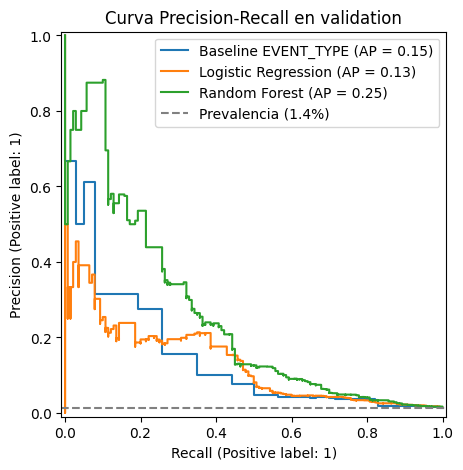

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(7, 5))
for nombre, proba in [("Baseline EVENT_TYPE", proba_tipo), ("Logistic Regression", proba_lr),
                      ("Random Forest", proba_rf)]:
    PrecisionRecallDisplay.from_predictions(y_val, proba, name=nombre, ax=ax)
ax.axhline(y_val.mean(), color="gray", linestyle="--", label=f"Prevalencia ({y_val.mean():.1%})")
ax.set_title("Curva Precision-Recall en validation")
ax.legend()
plt.show()

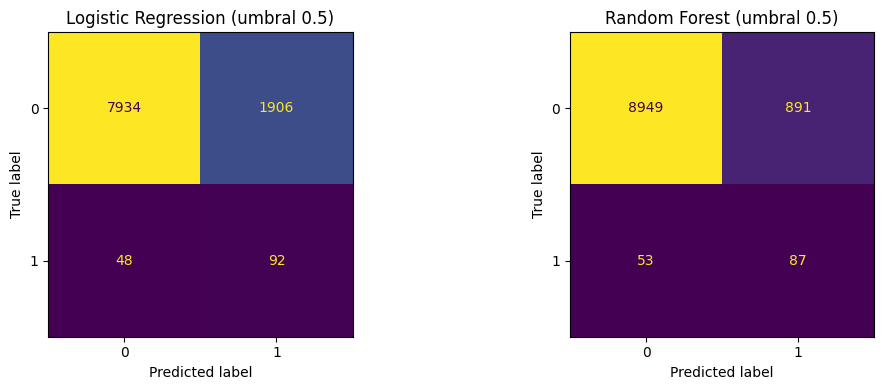

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (nombre, proba) in zip(axes, [("Logistic Regression", proba_lr), ("Random Forest", proba_rf)]):
    ConfusionMatrixDisplay.from_predictions(y_val, (proba >= 0.5).astype(int), ax=ax,
                                            colorbar=False, values_format="d")
    ax.set_title(f"{nombre} (umbral 0.5)")
plt.tight_layout()
plt.show()

### **Lo que muestran los datos**

* **Dummy:** PR-AUC 0.014 (igual a la prevalencia) y ROC-AUC 0.5. Como su probabilidad es siempre 0.014, con umbral 0.5 no
  marca ningún evento como alto impacto y su precision, recall, F1 y F2 valen 0. Es lo esperable con 1.4 % de positivos.
* **Baseline por EVENT_TYPE:** PR-AUC **0.145**, unas diez veces la prevalencia: el tipo de evento por sí solo ya ordena
  bastante bien. Con umbral 0.5 solo marca 6 eventos (los de *Rip Current*, el único tipo con tasa mayor a 0.5 en train),
  así que su recall es 0.029.
* **Regresión logística:** PR-AUC **0.132**, un poco por debajo del baseline por tipo, y ROC-AUC 0.815, un poco por encima.
  Con umbral 0.5 marca 1,998 eventos: recall 0.657, pero precision de solo 0.046.
* **Random Forest:** el mayor PR-AUC (**0.252**) y el mayor ROC-AUC (≈ 0.85). Con umbral 0.5 marca bastantes menos eventos que
  la regresión logística (ver matriz de confusión), con recall alrededor de 0.6 y precision menor a 0.1; tiene el mayor F1 y F2.
* Los ROC-AUC (0.81 a 0.85) se ven altos aunque la precision sea muy baja; por eso la métrica principal es PR-AUC.

### **Interpretación**

* **¿Superan a Dummy?** Sí: el baseline por tipo, la regresión logística y Random Forest tienen un PR-AUC muy superior a la
  prevalencia.
* **¿Superan al baseline por EVENT_TYPE?** Solo Random Forest, con una diferencia clara (0.252 frente a 0.145). La regresión
  logística queda prácticamente igual que el baseline: la diferencia (0.132 frente a 0.145) es pequeña. Una posible
  explicación, que no comprobamos, es que un modelo lineal suma los efectos por separado y no captura combinaciones como
  "tipo de evento + estado", mientras que Random Forest sí puede hacerlo.
* **Precision vs. recall con umbral 0.5:** con `class_weight="balanced"` los modelos tratan a las dos clases como si fueran
  igual de frecuentes, así que sus probabilidades quedan infladas y el umbral 0.5 marca muchos eventos. Se detecta más de la
  mitad de los positivos, pero la mayoría de las alertas son falsas. Elegir un umbral adecuado (sin usar el test) queda para el TF1.
* **¿Hay un modelo definitivamente superior?** Todavía no. Validation tiene solo 140 positivos: cada positivo detectado o
  perdido mueve el recall en 0.7 puntos porcentuales. La ventaja de Random Forest es la mayor que observamos y conviene
  confirmarla con validación cruzada en el TF1; por ahora es el mejor desempeño **preliminar**, no el modelo final. La
  diferencia entre la regresión logística y el baseline por tipo no es concluyente.

# 10. Hallazgos, limitaciones y plan hacia TF1

**1. El problema está muy desbalanceado y el target depende sobre todo de las víctimas.**

Solo 1,014 de 72,360 eventos (1.40 %) son de alto impacto. De ellos, 779 tienen víctimas y 281 tienen un daño de al menos USD 1 millón (46 cumplen las dos condiciones). Por eso descartamos la accuracy desde el inicio: un modelo que nunca marque un evento tendría 98.6 % de accuracy, pero en la práctica no nos serviría para detectar los eventos que nos interesan.

**2. El tipo de evento es la variable más informativa, lo que hace que superar el baseline no sea tan sencillo.**

La tasa de alto impacto va de 22.6 % en *Wildfire*, 19.8 % en *Lightning* y 8.0 % en *Tornado* hasta 0.18 % en *Hail*. Un baseline que solo usa el tipo de evento ya llega a un PR-AUC de **0.145**, cerca de diez veces la prevalencia. Al inicio pensábamos que sería fácil superar este resultado, pero los modelos no lo hicieron tan fácilmente.

**3. Solo Random Forest supera claramente al baseline por tipo.**

Random Forest obtiene un PR-AUC de **0.252** (≈ 18 veces la prevalencia), frente a 0.145 del baseline. La regresión logística queda en 0.132, por lo que ni siquiera mejora el resultado que ya obteníamos usando solamente el tipo de evento. Una posible explicación es que Random Forest puede captar combinaciones entre variables, como tipo + estado o tipo + magnitud, que la regresión logística no captura de la misma forma. Por ahora esto es solo una hipótesis y tendría que comprobarse con un análisis más específico.

**4. Con umbral 0.5 los modelos detectan bastantes eventos, pero muchas de las alertas son falsas.**

Random Forest marca 978 eventos en validation y detecta unos 87 de los 140 positivos (recall 0.621), pero su precision es 0.089: aproximadamente 1 de cada 11 alertas corresponde realmente a un evento de alto impacto. El baseline por tipo hace prácticamente lo contrario: tiene una precision de 0.667, pero solo marca 6 eventos y su recall es 0.029. Por lo tanto, ninguno de los dos resultados sería útil tal como está.

Creemos que esto puede estar relacionado con el umbral de 0.5 y con el uso de `class_weight="balanced"`, más que con que los modelos sean necesariamente malos. Esto todavía tenemos que comprobarlo buscando un umbral que se ajuste mejor al objetivo del problema.

**5. Las variables que más ayudaban eran justamente las que no podíamos usar.**

`SOURCE` (por ejemplo, *County Official* con 41.4 %), la escala EF, la duración y las narrativas tienen una relación fuerte con el alto impacto, pero aparecen después de t₀ o se asignan según el daño ocurrido. Si las hubiéramos usado, las métricas probablemente serían mucho mejores, pero el modelo estaría usando información que no estaría disponible al momento de generar la alerta.

Por eso, para nosotros fue importante identificar estas variables durante la auditoría de la sección 4 y dejarlas fuera del modelo, aunque eso haga que el resultado final sea más modesto.

**Conclusión preliminar.** Sí hay señal para priorizar eventos usando únicamente información disponible en t₀, y Random Forest aprovecha esa información mejor que el baseline por tipo. Sin embargo, un PR-AUC de 0.25 todavía es modesto y, con solo 140 positivos en validation, no podemos asegurar que esta ventaja se mantenga en otros conjuntos de datos. Por ahora, Random Forest es nuestro mejor resultado **preliminar**, no un modelo final.


## 10.2 Limitaciones

### Sobre el target

* **Es "alto impacto documentado", no necesariamente alto impacto real.** El 20.6 % de los eventos (14,927) no tiene información documentada de daño. Estos valores no se imputan como cero. Si el registro tampoco documenta víctimas, el evento queda como negativo bajo nuestro target de alto impacto documentado, aunque su impacto real sea incierto. Solo 48 de estos eventos son positivos, así que es posible que haya eventos de alto impacto entre los que quedaron como negativos. Un ejemplo claro es un tornado EF5 sin daño informado que terminó clasificado como "no alto impacto".

* **El daño puede estar incompleto.** En 3,691 eventos solo se registró uno de los dos componentes (propiedad o cultivos), por lo que `dano_total` podría estar por debajo del daño real. Esto significa que algunos eventos podrían no haber llegado al millón de dólares por falta de información y no porque realmente tuvieran menos daño.

* **Hay decisiones propias del equipo.** El umbral de USD 1 millón y la inclusión de víctimas indirectas (198 positivos que existen solo por esta condición) son decisiones que tomamos nosotros. Están justificadas en la sección 3, pero si estas reglas cambian, también cambiaría el target y, por lo tanto, el problema que estamos intentando resolver.

### Sobre los datos

* **Solo usamos un año y solo EE. UU.** Trabajamos con datos de 2025, así que no sabemos si los patrones encontrados se mantienen en otros años o si el modelo funcionaría de la misma manera en otros países.

* **Los datos no representan información disponible en tiempo real.** NOAA revisa los registros después de que ocurre el evento. Aunque seleccionamos variables que consideramos compatibles con t₀, sus valores ya pasaron por un proceso de registro y revisión. Por eso, nuestros resultados pueden ser mejores que los que obtendríamos en un escenario completamente en tiempo real. En particular, `MAGNITUDE_TYPE` y `viento_


## 10.3 Plan hacia TF1

Ordenamos el trabajo empezando por los puntos que más pueden afectar la confiabilidad de los resultados. El conjunto de test se mantiene separado y no se utilizará para tomar decisiones durante este proceso.

| # | Qué haremos                                    | Por qué (limitación que ataca)                                                                                           | Cómo                                                                                                                                                                                                                                        |
| - | ---------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1 | **Validación cruzada agrupada por episodio**   | Validation tiene solo 140 positivos y actualmente depende de una sola partición                                          | Usar `StratifiedGroupKFold` sobre train + validation, agrupando por `EPISODE_ID`. Reportaremos el promedio y la desviación del PR-AUC, además de un intervalo por bootstrap a nivel de episodio.                                            |
| 2 | **Elegir el umbral sin usar el test**          | Con 0.5 tenemos demasiadas falsas alarmas                                                                                | Usar la curva precision-recall de la validación cruzada y comparar un umbral que maximice F2 con otro que marque un porcentaje fijo de eventos (precision@k, recall@k). Esto sería más realista si la capacidad de respuesta es limitada.   |
| 3 | **Ajustar hiperparámetros**                    | Los parámetros de Random Forest se fijaron manualmente                                                                   | Hacer una búsqueda acotada de `n_estimators`, `min_samples_leaf`, `max_depth` y `max_features` dentro de la validación cruzada.                                                                                                             |
| 4 | **Probar otros modelos**                       | Todavía no sabemos si Random Forest es realmente la mejor opción ni por qué la regresión logística no mejora el baseline | Probar un modelo de boosting (`HistGradientBoostingClassifier`) y una regresión logística con interacciones tipo × estado, para comprobar la hipótesis planteada anteriormente.                                                             |
| 5 | **Evaluar más predictores compatibles con t₀** | Actualmente solo usamos seis variables                                                                                   | Agregar progresivamente `WFO`, hora de inicio y `CZ_TYPE`, y conservarlas solo si mejoran el resultado en validación cruzada. Con `WFO` tendremos especial cuidado porque podría estar capturando diferencias en las prácticas de registro. |
| 6 | **Interpretar el modelo y revisar errores**    | La interpretabilidad quedó pendiente                                                                                     | Calcular importancia por permutación y revisar las métricas por tipo de evento, `estado_dano` y zona marítima.                                                                                                                              |
| 7 | **Hacer pruebas de sensibilidad**              | El target depende de algunas decisiones propias del equipo                                                               | Repetir el análisis usando umbrales de daño de USD 100 mil y 10 millones, y también sin considerar víctimas indirectas. Además, revisar la hipótesis sobre las ráfagas EG quitando `MAGNITUDE_TYPE`.                                        |
| 8 | **Probar una separación por fechas**           | Todavía existe un posible riesgo de que episodios relacionados queden repartidos entre train y validation                | Entrenar con los primeros meses y validar con los últimos para comprobar si el desempeño se mantiene cuando el modelo se enfrenta a eventos posteriores.                                                                                    |
| 9 | **Evaluar en test una sola vez**               | Queremos evitar tomar decisiones mirando el resultado final                                                              | Congelar el modelo, el umbral y las variables antes de usar test. Después reportaremos el resultado obtenido, incluso si es menor que el de validation.                                                                                     |

**Cómo decidiremos el modelo final.** Escogeremos el modelo que tenga el mejor PR-AUC promedio en la validación cruzada, siempre que la mejora frente al baseline por tipo sea mayor que la variación observada entre los folds. Si no conseguimos superar al baseline de forma consistente, lo reportaremos tal cual: en ese caso, seguir usando el tipo de evento sería la conclusión más honesta.

**Qué podría salir mal.** Es posible que al hacer la validación cruzada la ventaja de Random Forest se reduzca, que los nuevos predictores aporten poco o incluso que el resultado en test sea menor que el obtenido en validation. Ninguno de estos resultados significa que el trabajo haya fallado, pero sí limitaría las conclusiones que podemos sacar. Por eso preferimos plantear estas posibilidades desde ahora en lugar de asumir que el modelo actual necesariamente va a mejorar.
